# Groundwater Age and Capture-Zone Examples

## Groundwater moves on a very different clock

Groundwater is part of the water cycle, but it usually moves much more slowly than the water we can easily see.

If you drop a leaf into a river, you can watch it move downstream in seconds. Groundwater is different. In many aquifers, water may move on the order of inches per day, or even slower. That slow movement matters.

Sometimes that slow pace is helpful. As water moves through the subsurface, parts of the aquifer can naturally "scrub" or reduce some contaminants. Slow movement also has consequences. Old groundwater may recharge gradually, and water pumped today may take years, decades, or centuries to be replaced.

That makes groundwater age a useful way to think about how renewable a water supply is. In this notebook, we ask a deliberately playful question with a serious purpose:

> On average, is groundwater in this aquifer as young as the **Star Wars sequel trilogy**, old enough to remember the **Expanded Universe novels**, or old enough to predate the **original trilogy** itself?

## Session Plan

The notebook follows the workshop conversation.

First, we run the model and generate the outputs we need. Then we use the outputs for discussion: groundwater age, all-well reverse-GWT capture-zone footprints, and matched six-well GWT/PRT examples for selected Illinois wells.


## 1. Imports

Before we can run the model or make maps, we load the Python tools used throughout the notebook.

The standard-library tools help the notebook find files and run external programs. The scientific tools support array calculations, tables, and plotting. The geospatial and MODFLOW tools let us read mapped data, work with model inputs and outputs, and visualize groundwater-model results.

This cell sets up the notebook’s working environment for the analysis that follows.

In [1]:
# Standard library tools
# pathlib makes file and folder paths easier to build and read across operating systems.
from pathlib import Path
# subprocess lets Python run external programs, such as the MODFLOW 6 executable.
import subprocess


# Scientific stack
# numpy supports fast numerical calculations and array operations.
import numpy as np
# pandas supports tables, summaries, and CSV-style outputs.
import pandas as pd
# matplotlib is used for plotting maps, charts, and diagnostic figures.
import matplotlib.pyplot as plt
# ListedColormap lets us define custom color categories, such as groundwater-age zones.
from matplotlib.colors import ListedColormap
# Patch lets us build clean custom legends for map categories.
from matplotlib.patches import Patch

# Geospatial / MODFLOW tools
# geopandas reads and plots geospatial files such as county boundaries or model-area shapefiles.
import geopandas as gpd
# flopy is the Python interface used to load, edit, run, and plot MODFLOW models.
import flopy
# binaryfile tools read MODFLOW binary outputs such as heads, budgets, and concentrations.
import flopy.utils.binaryfile as bf


## 2. Paths and age-model settings

This cell defines the working setup for the first part of the notebook: where the base model lives, where the groundwater-age model will be written, which MODFLOW 6 executable will run the simulation, and which map layers will be used for context.

The age calculation uses model layer 9 as the focus layer for maps. Python uses zero-based indexing, so model layer 9 is written as `analysis_layer = 8`.

The notebook also defines a single effective porosity value, `transport_porosity = 0.15`, for the transport calculations. Groundwater age depends on flow velocity through pore space, so this value is part of the time-scale story. The same porosity value is used again later when the notebook turns to particle tracking, keeping the travel-time assumptions consistent.

The base groundwater-flow model is steady-state. Pumping, recharge, and aquifer properties represent one modeled flow condition; the age model asks what that flow condition implies for groundwater residence time.


In [2]:
notebook_dir = Path.cwd()
home_dir = notebook_dir.parent

sim_name = "mfsim"
base_model_workspace = Path(home_dir / "modflow_models" / "iisg_local_model")
age_model_workspace = Path(home_dir / "modflow_models" / "groundwater_age_model")

exe_name = Path(home_dir / "bin" / "mf6_latest_2026-04.exe")
county_shapefile = Path(home_dir / "shapefiles" / "counties_5070.shp")

# Shared map / transport settings for the groundwater-age section.
analysis_layer = 8  # zero-based; 8 = model layer 9
days_per_year = 365.25
transport_porosity = 0.15

# Groundwater-age run settings.
age_length_years = 500.0
age_length_days = days_per_year * age_length_years
age_time_steps = 25
age_timestep_mult = 1.05
run_age_model = True

# Map windows.
local_map_x_min = 680000.0
local_map_x_max = 700000.0
local_map_y_min = 2.08e6
local_map_y_max = 2.10e6
active_domain_pad_cells = 5

setup_summary = pd.DataFrame(
    [
        {"item": "Base groundwater model", "value": str(base_model_workspace)},
        {"item": "Groundwater-age workspace", "value": str(age_model_workspace)},
        {"item": "MODFLOW 6 executable", "value": str(exe_name)},
        {"item": "Mapped model layer", "value": f"Layer {analysis_layer + 1}"},
        {"item": "Transport porosity", "value": transport_porosity},
        {"item": "Age simulation length", "value": f"{age_length_years:g} years"},
    ]
)
display(setup_summary)


,item,value
0,Base groundwater model,C:\Users\dbabrams\Documents\GitHub\ISWS-Chi-Wa...
1,Groundwater-age workspace,C:\Users\dbabrams\Documents\GitHub\ISWS-Chi-Wa...
2,MODFLOW 6 executable,C:\Users\dbabrams\Documents\GitHub\ISWS-Chi-Wa...
3,Mapped model layer,Layer 9
4,Transport porosity,0.15
5,Age simulation length,500 years


## 3. Load the base groundwater-flow model

The base model is the starting point for the age analysis. It contains the model grid, aquifer properties, boundary conditions, wells, and the steady-state groundwater-flow solution.

This cell reads the already-prepared MODFLOW 6 simulation, checks the model name, and stores the groundwater-flow model object so later cells can copy it, read outputs from it, and use its hydraulic information.

In [3]:
base_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=base_model_workspace,
    write_headers=False,
    exe_name=exe_name,
)

base_model_name = list(base_sim.model_names)[0]
base_gwf = base_sim.get_model(base_model_name)

base_grid_summary = pd.DataFrame(
    [
        {"item": "Loaded groundwater-flow model", "value": base_model_name},
        {"item": "Model layers", "value": int(base_gwf.dis.nlay.array)},
        {"item": "Rows", "value": int(base_gwf.dis.nrow.array)},
        {"item": "Columns", "value": int(base_gwf.dis.ncol.array)},
        {"item": "Focus layer for maps", "value": f"Layer {analysis_layer + 1}"},
    ]
)
display(base_grid_summary)


loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package rch...
    loading package oc...
    loading package ghb...
    loading package sfr...
    loading package wel...
    loading package obs...
    loading package drn...
  loading solution package gwf-iisg...


,item,value
0,Loaded groundwater-flow model,gwf-iisg
1,Model layers,10
2,Rows,847
3,Columns,569
4,Focus layer for maps,Layer 9


## 4. Flow-field context: heads and groundwater movement

Groundwater age depends on the flow field. Before calculating age, it helps to look at the steady-state heads and the simulated flow directions in the focus layer.

Heads show the modeled groundwater-level surface. Flow arrows show the direction water tends to move through the model. Together, they provide the physical context for the age map that follows.

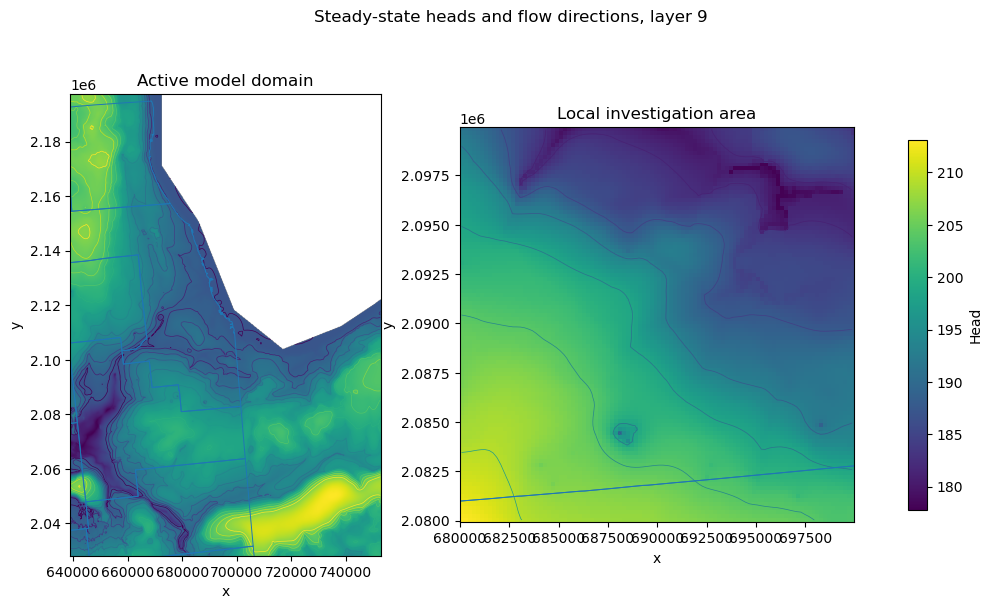

,item,value
0,Head output time,1.0
1,Focus layer,Layer 9
2,Head range in active cells,148.87 to 256.43
3,Flow-direction arrows,Head contours shown; specific-discharge vector...


In [4]:
# ---------------------------------------------------------------------
# Plot steady-state heads and flow directions for the focus layer.
# ---------------------------------------------------------------------
# The arrows are based on specific-discharge output if that output is
# available in the base model budget file.

base_headobj = base_gwf.output.head()
base_head_times = base_headobj.get_times()
if len(base_head_times) == 0:
    raise RuntimeError("No base-model head output was found. Run the base model first.")

base_flow_time = base_head_times[-1]
base_heads = np.asarray(base_headobj.get_data(totim=base_flow_time), dtype=float)
base_idomain = np.asarray(base_gwf.dis.idomain.array)

head_layer = base_heads[analysis_layer].copy()
head_layer = np.where(base_idomain[analysis_layer] > 0, head_layer, np.nan)
head_layer[(head_layer > 1.0e20) | (head_layer < -1.0e20)] = np.nan

# Try to read specific discharge for arrows.
qx = qy = None
vector_note = "Flow arrows available"
try:
    base_budget = base_gwf.output.budget()
    spdis = base_budget.get_data(text="DATA-SPDIS", totim=base_flow_time)[0]
    qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, base_gwf)
except Exception:
    vector_note = "Head contours shown; specific-discharge vectors were not available in the base output."

xcenters = np.asarray(base_gwf.modelgrid.xcellcenters, dtype=float)
ycenters = np.asarray(base_gwf.modelgrid.ycellcenters, dtype=float)

active_any = np.any(base_idomain > 0, axis=0)
active_rows, active_cols = np.where(active_any)
row0 = max(int(active_rows.min()) - active_domain_pad_cells, 0)
row1 = min(int(active_rows.max()) + active_domain_pad_cells + 1, active_any.shape[0])
col0 = max(int(active_cols.min()) - active_domain_pad_cells, 0)
col1 = min(int(active_cols.max()) + active_domain_pad_cells + 1, active_any.shape[1])

local_mask = (
    active_any
    & (xcenters >= local_map_x_min)
    & (xcenters <= local_map_x_max)
    & (ycenters >= local_map_y_min)
    & (ycenters <= local_map_y_max)
)
if np.any(local_mask):
    lr, lc = np.where(local_mask)
    lrow0, lrow1 = int(lr.min()), int(lr.max()) + 1
    lcol0, lcol1 = int(lc.min()), int(lc.max()) + 1
else:
    lrow0, lrow1, lcol0, lcol1 = row0, row1, col0, col1


def _extent_for_window(r0, r1, c0, c1):
    xs = xcenters[r0:r1, c0:c1]
    ys = ycenters[r0:r1, c0:c1]
    dx = np.nanmedian(np.abs(np.diff(xcenters, axis=1)))
    dy = np.nanmedian(np.abs(np.diff(ycenters, axis=0)))
    return [np.nanmin(xs) - dx / 2, np.nanmax(xs) + dx / 2, np.nanmin(ys) - dy / 2, np.nanmax(ys) + dy / 2]

try:
    counties_flow = gpd.read_file(county_shapefile)
    model_crs = base_gwf.modelgrid.crs
    if model_crs is not None and counties_flow.crs is not None and counties_flow.crs != model_crs:
        counties_flow = counties_flow.to_crs(model_crs)
except Exception:
    counties_flow = None

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
windows = [
    (row0, row1, col0, col1, "Active model domain"),
    (lrow0, lrow1, lcol0, lcol1, "Local investigation area"),
]

valid_heads = head_layer[np.isfinite(head_layer)]
levels = np.linspace(np.nanpercentile(valid_heads, 5), np.nanpercentile(valid_heads, 95), 12) if valid_heads.size else 10

for ax, (r0, r1, c0, c1, title) in zip(axes, windows):
    extent = _extent_for_window(r0, r1, c0, c1)
    im = ax.imshow(
        np.ma.masked_invalid(head_layer[r0:r1, c0:c1]),
        origin="upper",
        extent=extent,
    )
    ax.contour(
        xcenters[r0:r1, c0:c1],
        ycenters[r0:r1, c0:c1],
        head_layer[r0:r1, c0:c1],
        levels=levels,
        linewidths=0.5,
    )

    if qx is not None and qy is not None:
        step = max(1, int(max(r1 - r0, c1 - c0) / 25))
        qx_plot = qx[analysis_layer, r0:r1:step, c0:c1:step]
        qy_plot = qy[analysis_layer, r0:r1:step, c0:c1:step]
        x_plot = xcenters[r0:r1:step, c0:c1:step]
        y_plot = ycenters[r0:r1:step, c0:c1:step]
        good = np.isfinite(qx_plot) & np.isfinite(qy_plot)
        ax.quiver(
            x_plot[good],
            y_plot[good],
            qx_plot[good],
            qy_plot[good],
            angles="xy",
            scale_units="xy",
            scale=None,
            width=0.002,
            alpha=0.75,
        )

    if counties_flow is not None:
        xmin, xmax, ymin, ymax = extent
        counties_flow.cx[xmin:xmax, ymin:ymax].boundary.plot(ax=ax, linewidth=0.7)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_aspect("equal")

fig.colorbar(im, ax=axes, shrink=0.8, label="Head")
fig.suptitle(f"Steady-state heads and flow directions, layer {analysis_layer + 1}", y=1.02)
plt.show()

flow_summary = pd.DataFrame(
    [
        {"item": "Head output time", "value": base_flow_time},
        {"item": "Focus layer", "value": f"Layer {analysis_layer + 1}"},
        {"item": "Head range in active cells", "value": f"{np.nanmin(valid_heads):.2f} to {np.nanmax(valid_heads):.2f}" if valid_heads.size else "not available"},
        {"item": "Flow-direction arrows", "value": vector_note},
    ]
)
display(flow_summary)


## 5. Create the groundwater-age working copy

The base model stays preserved as the reference model. This cell writes a separate working copy for the groundwater-age calculation, then reloads that copy from its own workspace.

Keeping a separate age-model workspace makes the workflow easier to trust. The copied model keeps the same grid and flow-system structure, while the notebook adds the transport pieces needed to calculate groundwater age.

In [5]:
base_sim.set_sim_path(age_model_workspace)
base_sim.write_simulation()

# Restore the base simulation path after writing the copy.
base_sim.set_sim_path(base_model_workspace)

age_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=age_model_workspace,
    write_headers=False,
    exe_name=exe_name,
)

age_model_name = list(age_sim.model_names)[0]
age_gwf = age_sim.get_model(age_model_name)

age_workspace_summary = pd.DataFrame(
    [
        {"item": "Groundwater-age model", "value": age_model_name},
        {"item": "Age workspace", "value": str(age_model_workspace)},
        {"item": "Workspace ready", "value": Path(age_gwf.model_ws) == age_model_workspace},
    ]
)
display(age_workspace_summary)


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf-iisg...
  writing model gwf-iisg...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package oc...
    writing package ghb_0...
    writing package sfr_obs...
    writing package sfr_0...
    writing package wel_obs...
    writing package wel_0...
    writing package obs_1...
    writing package drn_0...
loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package rch...
    loading package oc...
    loading package ghb...
    loading package sfr...
    loading package wel...
    loading package obs...
    loading package drn...
  loading solution package gwf-iisg...


,item,value
0,Groundwater-age model,gwf-iisg
1,Age workspace,C:\Users\dbabrams\Documents\GitHub\ISWS-Chi-Wa...
2,Workspace ready,True


## 6. Initialize groundwater-age starting heads

The groundwater-age run starts from the steady-state head solution produced by the base model. That keeps the age calculation tied to the same hydraulic condition used elsewhere in the workflow.

This cell reads the final head output from the base model and uses it as the starting head field in the age-model copy. Inactive cells and invalid head values are handled carefully so the age simulation begins from a reasonable, already-solved groundwater-flow condition.

In [6]:
base_headobj = base_gwf.output.head()
base_head_times = base_headobj.get_times()

if len(base_head_times) == 0:
    raise RuntimeError(
        "No base-model head output was found. Run the base model first, then rerun this cell."
    )

base_final_time = base_head_times[-1]
base_final_heads = np.array(base_headobj.get_data(totim=base_final_time), dtype=float)

age_start_heads = base_final_heads.copy()
current_start_heads = np.array(age_gwf.ic.strt.array, dtype=float)
idomain = np.array(age_gwf.dis.idomain.array)

bad_heads = (
    ~np.isfinite(age_start_heads)
    | (age_start_heads > 1.0e20)
    | (age_start_heads < -1.0e20)
    | (idomain <= 0)
)

age_start_heads[bad_heads] = current_start_heads[bad_heads]
age_gwf.ic.strt.set_data(age_start_heads)

initial_head_summary = pd.DataFrame(
    [
        {"item": "Starting heads copied from base model time", "value": base_final_time},
        {"item": "Initial head range", "value": f"{np.nanmin(age_start_heads):.2f} to {np.nanmax(age_start_heads):.2f}"},
    ]
)
display(initial_head_summary)


,item,value
0,Starting heads copied from base model time,1.0
1,Initial head range,29.38 to 257.13


## 7. Configure the groundwater-age run

This cell defines the time discretization for the groundwater-age simulation. The age model is run long enough for regional residence-time patterns to emerge across the aquifer system.

The result should be read as a model-based groundwater-age pattern. Each mapped value reflects the simulated flow field, boundary conditions, porosity assumption, and transport setup.

For discussion, the useful question is where the model suggests groundwater is relatively young and connected, and where it appears older, slower, or more isolated. The map helps turn an underground time scale into something the group can inspect together.

In [7]:
age_num_periods = 1

age_time_dis = age_sim.get_package("tdis")
age_time_dis.nper = age_num_periods
age_time_dis.perioddata = [
    (age_length_days, age_time_steps, age_timestep_mult)
]

age_timing_summary = pd.DataFrame(
    [
        {"item": "Age simulation length", "value": f"{age_length_years:g} years"},
        {"item": "Transport time steps", "value": age_time_steps},
        {"item": "Time-step multiplier", "value": age_timestep_mult},
    ]
)
display(age_timing_summary)


,item,value
0,Age simulation length,500 years
1,Transport time steps,25
2,Time-step multiplier,1.05


## 8. Build the groundwater-age transport model

Here the notebook adds a groundwater-transport model to the copied groundwater-flow simulation. In this section, the transported quantity is **groundwater age**.

The idea is simple and powerful: newly recharged water enters the model with age zero, and every day that a parcel of groundwater remains in the aquifer, its age increases by one day. That age signal is carried through the flow field in the same way another transported quantity would move through the model.

This cell adds the transport packages needed to represent that process. One package defines the transport grid and time discretization. Another defines porosity, which controls how fast water moves through pore space. The advection and dispersion packages govern how the age signal moves and spreads through the aquifer. The mass-storage package keeps track of the age carried in groundwater storage. Source and sink terms tell the model that recharge and inflow boundaries bring in young water, while pumping and outflow boundaries remove whatever age is present.

This cell also connects the groundwater-flow model and groundwater-transport model so the age calculation uses the simulated flow field. The final output is written in a concentration-style file, while the stored value represents age. When we later divide by 365.25, the map is shown in years.


In [8]:
age_gwt_name = f"{age_model_name}_gwt"

age_gwt = flopy.mf6.ModflowGwt(
    age_sim,
    modelname=age_gwt_name,
)

flopy.mf6.ModflowGwtdis(
    age_gwt,
    nlay=age_gwf.dis.nlay.array,
    nrow=age_gwf.dis.nrow.array,
    ncol=age_gwf.dis.ncol.array,
    delr=age_gwf.dis.delr.array,
    delc=age_gwf.dis.delc.array,
    top=age_gwf.dis.top.array,
    botm=age_gwf.dis.botm.array,
    idomain=age_gwf.dis.idomain.array,
    xorigin=age_gwf.modelgrid.xoffset,
    yorigin=age_gwf.modelgrid.yoffset,
    angrot=age_gwf.modelgrid.angrot,
)



# Initial age concentration = 0 everywhere.
flopy.mf6.ModflowGwtic(
    age_gwt,
    strt=0.0,
)

flopy.mf6.ModflowGwtadv(
    age_gwt,
    scheme="UPSTREAM",
)

# Use one explicit porosity value for the groundwater-age transport calculation.
porosity = np.full(
    (
        age_gwf.modelgrid.nlay,
        age_gwf.modelgrid.nrow,
        age_gwf.modelgrid.ncol,
    ),
    transport_porosity,
    dtype=float,
)


# Groundwater-age trick:
# zero-order decay with negative decay produces age concentration over time.
age_decay_rate = -1.0  # age units per model day

flopy.mf6.ModflowGwtmst(
    age_gwt,
    porosity=porosity,
    zero_order_decay=True,
    decay=age_decay_rate,
    save_flows=False,
)

# Treat source water as zero-age water.
flopy.mf6.ModflowGwtssm(age_gwt)

# Save only the final total-age concentration field.
flopy.mf6.ModflowGwtoc(
    age_gwt,
    concentration_filerecord=f"{age_gwt_name}.ucn",
    saverecord=[
        ("CONCENTRATION", "LAST"),
    ],
)

# Add MVT if the GWF model has movers.
has_mvr = any("MVR" in package_name.upper() for package_name in age_gwf.get_package_list())

if has_mvr:
    flopy.mf6.ModflowGwtmvt(
        age_gwt,
        save_flows=True,
    )

# Solver settings
age_ims = flopy.mf6.ModflowIms(
    age_sim,
    filename=f"{age_gwt.name}.ims",
    print_option="summary",
    complexity="simple",
    outer_maximum=100,
    inner_maximum=50,
    outer_dvclose=1.0e-2,
    inner_dvclose=1.0e-2,
    linear_acceleration="bicgstab",
)

age_sim.register_ims_package(
    age_ims,
    model_list=[f"{age_gwt.name}"],
)

# link MOdfLOW GWF to GWT- IMPORTANT
flopy.mf6.ModflowGwfgwt(
    age_sim,
    exgtype="GWF6-GWT6",
    exgmnamea=age_gwf.name,
    exgmnameb=age_gwt.name,
)

age_transport_summary = pd.DataFrame(
    [
        {"item": "Groundwater-age transport model", "value": age_gwt_name},
        {"item": "Porosity used for age calculation", "value": transport_porosity},
        {"item": "Age output", "value": "Final total-age field"},
    ]
)
display(age_transport_summary)

,item,value
0,Groundwater-age transport model,gwf-iisg_gwt
1,Porosity used for age calculation,0.15
2,Age output,Final total-age field


## 9. Run the groundwater-age model

In this example, we are going to run a coupled groundwater flow and transport model in real time, in tandem. As you will see, this is actually really fast, because we don't have to iteratively save flow files (which are large) and pass those back and forth; the model receives that information in real-time. 

When we are done, we will have one saved combined flow and transport solution at the end of the simulation, 500 days. Note that this code writes and runs both. 


In [22]:
age_sim.write_simulation()

if run_age_model:
    success, buff = age_sim.run_simulation()
    if success:
        print("Groundwater-age simulation completed successfully.")
    else:
        raise RuntimeError("Groundwater age simulation failed. Check the listing file.")
else:
    print("Groundwater-age simulation was written. The run flag is off, so existing outputs will be used if available.")


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package gwf-iisg...
  writing solution package ims_0...
  writing package mfsim.gwfgwt...
  writing model gwf-iisg...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package oc...
    writing package ghb_0...
    writing package sfr_obs...
    writing package sfr_0...
    writing package wel_obs...
    writing package wel_0...
    writing package obs_1...
    writing package drn_0...
  writing model gwf-iisg_gwt...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package adv...
    writing package mst...
    writing package ssm...
    writing package oc...
FloPy is using the following executable to run the model: ..\..\bin\mf6_latest_2026-04.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVE

## 10. Plot total groundwater age

The total-age map shows the final simulated groundwater age for the selected model layer. The figure is clipped to the active model domain so the map focuses on the modeled aquifer area.

This map is the regional context for the rest of the notebook. Younger areas suggest faster connection to recharge or boundary inflows. Older areas suggest slower movement, longer residence time, or parts of the system where water may take much longer to be replaced.

The color scale is intentionally capped for readability. Very old values can exist, and the cap keeps a few extreme cells from controlling the entire color scale during discussion.

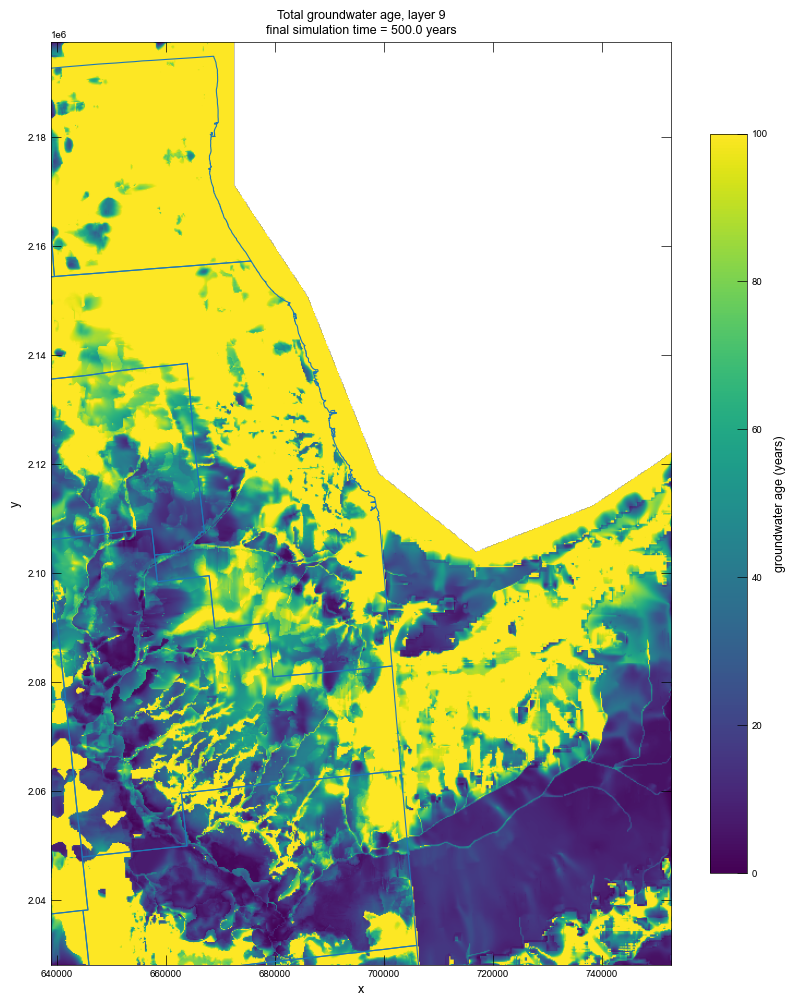

,item,value
0,Mapped layer,Layer 9
1,Displayed age range,0 to 100 years
2,Final model time,500.0 years
3,Map view,Active model domain


In [10]:
# This keeps the whole active model domain visible while trimming the large
# inactive/blank grid area around it.

age_plot_layer = analysis_layer
plot_age_in_years = True
age_domain_pad_cells = 5

ucn = age_gwt.output.concentration()
times = ucn.get_times()

if len(times) == 0:
    raise RuntimeError("No groundwater-age concentration output was found.")

final_time = times[-1]
age_conc = np.array(ucn.get_data(totim=final_time), dtype=float)

age_map = age_conc[age_plot_layer].copy()
age_map[age_map > 1.0e20] = np.nan
age_map[age_map < -1.0e20] = np.nan

idomain = np.array(age_gwf.dis.idomain.array)
age_map = np.where(idomain[age_plot_layer] > 0, age_map, np.nan)

if plot_age_in_years:
    age_map = age_map / 365.25
    age_units = "years"
else:
    age_units = "days"

active_any_layer = np.any(idomain > 0, axis=0)
active_rows, active_cols = np.where(active_any_layer)

if active_rows.size == 0 or active_cols.size == 0:
    raise RuntimeError("No active cells found in idomain.")

row_start = max(int(active_rows.min()) - age_domain_pad_cells, 0)
row_end = min(int(active_rows.max()) + age_domain_pad_cells + 1, age_map.shape[0])
col_start = max(int(active_cols.min()) - age_domain_pad_cells, 0)
col_end = min(int(active_cols.max()) + age_domain_pad_cells + 1, age_map.shape[1])

age_map_zoom = age_map[row_start:row_end, col_start:col_end]

xcenters = age_gwf.modelgrid.xcellcenters
ycenters = age_gwf.modelgrid.ycellcenters

x_zoom = xcenters[row_start:row_end, col_start:col_end]
y_zoom = ycenters[row_start:row_end, col_start:col_end]

dx = np.nanmedian(np.abs(np.diff(xcenters, axis=1)))
dy = np.nanmedian(np.abs(np.diff(ycenters, axis=0)))

if not np.isfinite(dx):
    dx = 0.0
if not np.isfinite(dy):
    dy = 0.0

x_min = np.nanmin(x_zoom) - dx / 2
x_max = np.nanmax(x_zoom) + dx / 2
y_min = np.nanmin(y_zoom) - dy / 2
y_max = np.nanmax(y_zoom) + dy / 2

valid_age = age_map_zoom[np.isfinite(age_map_zoom)]

if valid_age.size > 0:
    vmin = 0.0
    vmax = np.nanpercentile(valid_age, 95)
else:
    vmin = 0.0
    vmax = 1.0

counties = gpd.read_file(county_shapefile)

try:
    model_crs = age_gwf.modelgrid.crs
except Exception:
    model_crs = None

if model_crs is not None and counties.crs is not None and counties.crs != model_crs:
    counties = counties.to_crs(model_crs)

counties_plot = counties.cx[x_min:x_max, y_min:y_max]

with flopy.plot.styles.USGSMap():
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.set_aspect("equal")

    im = ax.imshow(
        np.ma.masked_invalid(age_map_zoom),
        origin="upper",
        extent=[x_min, x_max, y_min, y_max],
        vmin=vmin,
        vmax=100, #vmax,
    )

    if len(counties_plot) > 0:
        counties_plot.boundary.plot(ax=ax, linewidth=0.8)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(
        f"Total groundwater age, layer {age_plot_layer + 1}\n"
        f"final simulation time = {final_time / 365.25:.1f} years"
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label(f"groundwater age ({age_units})")

    plt.show()

age_map_summary = pd.DataFrame(
    [
        {"item": "Mapped layer", "value": f"Layer {age_plot_layer + 1}"},
        {"item": "Displayed age range", "value": f"0 to {100:g} {age_units}"},
        {"item": "Final model time", "value": f"{final_time / 365.25:.1f} years"},
        {"item": "Map view", "value": "Active model domain"},
    ]
)
display(age_map_summary)


### Groundwater-age categories for discussion

The next map groups the simulated age field into a few recognizable time ranges. The labels are playful, and the categories are doing real work: they help translate a continuous age map into intervals that are easier to discuss in a room.

The categories are based on familiar Star Wars release eras: recent sequel-era water, Clone Wars-era water, prequel-era water, Expanded Universe-era water, original-trilogy-era water, and groundwater old enough to predate the original Star Wars release altogether.


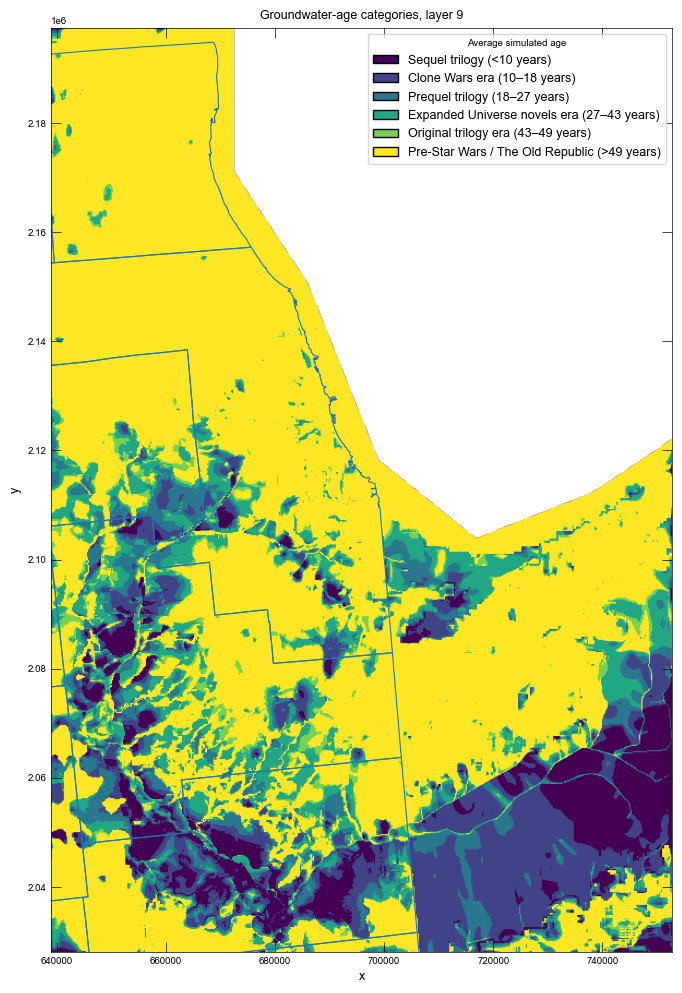

,Age category,Age range used on map
0,Sequel trilogy (<10 years),0–10 years
1,Clone Wars era (10–18 years),10–18 years
2,Prequel trilogy (18–27 years),18–27 years
3,Expanded Universe novels era (27–43 years),27–43 years
4,Original trilogy era (43–49 years),43–49 years
5,Pre-Star Wars / The Old Republic (>49 years),>49 years


In [11]:
from matplotlib.colors import BoundaryNorm

star_wars_bins = [0, 10, 18, 27, 43, 49, np.inf]
star_wars_labels = [
    "Sequel trilogy (<10 years)",
    "Clone Wars era (10–18 years)",
    "Prequel trilogy (18–27 years)",
    "Expanded Universe novels era (27–43 years)",
    "Original trilogy era (43–49 years)",
    "Pre-Star Wars / The Old Republic (>49 years)",
]
star_wars_ranges = [
    "0–10 years",
    "10–18 years",
    "18–27 years",
    "27–43 years",
    "43–49 years",
    ">49 years",
]

# Classify the already plotted age map. age_map_zoom is in years because
# plot_age_in_years = True in the total-age plotting cell above.
age_classes = np.digitize(age_map_zoom, star_wars_bins, right=False) - 1
age_classes = np.where(np.isfinite(age_map_zoom), age_classes, np.nan)

cmap = plt.get_cmap("viridis", len(star_wars_labels))
norm = BoundaryNorm(
    np.arange(-0.5, len(star_wars_labels) + 0.5, 1),
    cmap.N,
)

with flopy.plot.styles.USGSMap():
    fig, ax = plt.subplots(figsize=(10, 12))
    ax.set_aspect("equal")

    im = ax.imshow(
        np.ma.masked_invalid(age_classes),
        origin="upper",
        extent=[x_min, x_max, y_min, y_max],
        cmap=cmap,
        norm=norm,
    )

    if len(counties_plot) > 0:
        counties_plot.boundary.plot(ax=ax, linewidth=0.8)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Groundwater-age categories, layer {age_plot_layer + 1}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    legend_handles = [
        Patch(facecolor=cmap(norm(i)), edgecolor="black", label=label)
        for i, label in enumerate(star_wars_labels)
    ]
    ax.legend(
        handles=legend_handles,
        title="Average simulated age",
        loc="upper right",
        frameon=True,
    )

    plt.show()

category_summary = pd.DataFrame(
    {"Age category": star_wars_labels, "Age range used on map": star_wars_ranges}
)
display(category_summary)


## 11. Reusable model and plotting helpers

The next few sections reuse a small set of helper functions for selecting pumping wells, finding map windows, and building release points. These functions keep the later cells focused on the maps and summaries rather than repeating the same bookkeeping steps.

In [12]:
def package_name(pkg):
    """Return a readable MF6 package name."""
    name = getattr(pkg, "package_name", None)
    if name is None:
        return getattr(pkg, "pname", None)
    if isinstance(name, (list, tuple)):
        return name[0]
    return str(name)


def first_package(model, package_type):
    """Return the first package of a given package type."""
    package_type = package_type.lower()
    matches = [
        pkg for pkg in model.packagelist
        if getattr(pkg, "package_type", "").lower() == package_type
    ]
    if not matches:
        raise RuntimeError(f"No {package_type.upper()} package found in model {model.name}.")
    return matches[0]


def final_heads_from_base(source_gwf, target_gwf):
    """Use the existing steady-state base heads as starting heads for a copied model."""
    headobj = source_gwf.output.head()
    times = headobj.get_times()
    if len(times) == 0:
        raise RuntimeError("No base-model head output was found. Run the base model first.")

    final_time = times[-1]
    heads = np.array(headobj.get_data(totim=final_time), dtype=float)

    target_start = np.array(target_gwf.ic.strt.array, dtype=float)
    idomain = np.array(target_gwf.dis.idomain.array)

    bad = (
        ~np.isfinite(heads)
        | (heads > 1.0e20)
        | (heads < -1.0e20)
        | (idomain <= 0)
    )
    heads[bad] = target_start[bad]
    return heads, final_time


def turn_on_flow_output(gwf):
    """Save the flow terms needed by particle tracking."""
    for pkg in gwf.packagelist:
        if hasattr(pkg, "save_flows"):
            try:
                pkg.save_flows.set_data(True)
            except Exception:
                pass

    gwf.npf.save_flows.set_data(True)
    gwf.npf.save_specific_discharge.set_data(True)
    gwf.npf.save_saturation.set_data(True)


def model_counties(gwf):
    counties = gpd.read_file(county_shapefile)
    model_crs = gwf.modelgrid.crs
    if model_crs is not None and counties.crs is not None and counties.crs != model_crs:
        counties = counties.to_crs(model_crs)
    return counties


def active_window(idomain, pad_cells=5):
    active = np.any(idomain > 0, axis=0)
    rows, cols = np.where(active)
    return (
        max(int(rows.min()) - pad_cells, 0),
        min(int(rows.max()) + pad_cells + 1, active.shape[0]),
        max(int(cols.min()) - pad_cells, 0),
        min(int(cols.max()) + pad_cells + 1, active.shape[1]),
    )


def xy_window(gwf, idomain, x_min, x_max, y_min, y_max):
    x = gwf.modelgrid.xcellcenters
    y = gwf.modelgrid.ycellcenters
    active = np.any(idomain > 0, axis=0)
    inside = active & (x >= x_min) & (x <= x_max) & (y >= y_min) & (y <= y_max)
    rows, cols = np.where(inside)
    if len(rows) == 0 or len(cols) == 0:
        raise RuntimeError("No active model cells found inside the requested local map window.")
    return int(rows.min()), int(rows.max()) + 1, int(cols.min()), int(cols.max()) + 1


def window_extent(gwf, row0, row1, col0, col1):
    x = gwf.modelgrid.xcellcenters
    y = gwf.modelgrid.ycellcenters
    dx = np.nanmedian(np.abs(np.diff(x, axis=1)))
    dy = np.nanmedian(np.abs(np.diff(y, axis=0)))
    return (
        float(np.nanmin(x[row0:row1, col0:col1]) - dx / 2),
        float(np.nanmax(x[row0:row1, col0:col1]) + dx / 2),
        float(np.nanmin(y[row0:row1, col0:col1]) - dy / 2),
        float(np.nanmax(y[row0:row1, col0:col1]) + dy / 2),
    )


def boundname_matches_any(boundname, patterns):
    """True if a WEL boundname matches any exclusion pattern."""
    if patterns is None:
        return False
    text = str(boundname).lower()
    return any(str(pattern).lower() in text for pattern in patterns)


def pumping_well_release_cells(gwf, kper=0, layer=None, boundname_prefix="wel_", exclude_name_patterns=None):
    """Return named extracting WEL-package cells for PRT release.

    The WEL package can include both actual named wells and perimeter/boundary
    flux records. For this PRT workflow, release particles from actual pumping-
    well cells only.
    """
    wel = first_package(gwf, "wel")
    data = wel.stress_period_data.get_data(key=kper)
    names = data.dtype.names

    if "q" not in names:
        raise RuntimeError(f"Could not find q field in WEL stress-period data. Fields: {names}")

    rows = []
    excluded_rows = []

    for idx, rec in enumerate(data):
        q = float(rec["q"])
        if q >= 0.0:
            continue

        if "cellid" in names:
            cellid = rec["cellid"]
            if isinstance(cellid, np.ndarray):
                cellid = cellid.tolist()
            k, i, j = [int(value) for value in tuple(cellid)]
        elif all(field in names for field in ["k", "i", "j"]):
            k, i, j = int(rec["k"]), int(rec["i"]), int(rec["j"])
        else:
            raise RuntimeError(f"Could not identify WEL cellid fields. Fields: {names}")

        boundname = str(rec["boundname"]) if "boundname" in names else ""

        excluded_reason = None
        if layer is not None and k != int(layer):
            excluded_reason = "outside_release_layer"
        elif boundname_prefix is not None and boundname_prefix != "" and not boundname.startswith(boundname_prefix):
            excluded_reason = "does_not_match_well_prefix"
        elif boundname_matches_any(boundname, exclude_name_patterns):
            excluded_reason = "matches_boundary_exclusion_pattern"

        if excluded_reason is not None:
            excluded_rows.append(
                {
                    "bndno": idx + 1,
                    "k": k,
                    "i": i,
                    "j": j,
                    "q": q,
                    "boundname": boundname,
                    "reason": excluded_reason,
                }
            )
            continue

        rows.append(
            {
                "bndno": idx + 1,
                "k": k,
                "i": i,
                "j": j,
                "q": q,
                "boundname": boundname,
            }
        )

    wells = pd.DataFrame(rows)
    excluded = pd.DataFrame(excluded_rows)

    if wells.empty:
        return [], wells, excluded, wel, package_name(wel)

    grouped = (
        wells.groupby(["k", "i", "j"], as_index=False)
        .agg(
            q_total=("q", "sum"),
            n_wel_records=("bndno", "count"),
            first_bndno=("bndno", "min"),
            boundnames=("boundname", lambda values: ", ".join(sorted(set(map(str, values)))[:5])),
        )
        .sort_values(["k", "i", "j"])
        .reset_index(drop=True)
    )

    cells = [tuple(map(int, row)) for row in grouped[["k", "i", "j"]].to_numpy()]
    return cells, grouped, excluded, wel, package_name(wel)


def circular_release_offsets(n_ring=8, radius=0.30, include_center=True):
    """Return localx/localy offsets for a center point plus a ring in one cell."""
    offsets = []
    if include_center:
        offsets.append({"release_position": "center", "localx": 0.5, "localy": 0.5})

    if n_ring > 0:
        for idx, theta in enumerate(np.linspace(0.0, 2.0 * np.pi, int(n_ring), endpoint=False)):
            localx = 0.5 + float(radius) * np.cos(theta)
            localy = 0.5 + float(radius) * np.sin(theta)
            if not (0.0 < localx < 1.0 and 0.0 < localy < 1.0):
                raise ValueError(
                    "Circular release radius is too large; local particle coordinates must stay inside the cell."
                )
            offsets.append({"release_position": f"ring_{idx + 1:02d}", "localx": localx, "localy": localy})

    return pd.DataFrame(offsets)


def choose_pumping_wells_for_reverse_gwt(gwf, kper=0, boundname_prefix="wel_", exclude_name_patterns=None):
    """Return WEL boundary numbers for named extracting wells used as reverse-GWT sources."""
    wel = first_package(gwf, "wel")
    data = wel.stress_period_data.get_data(key=kper)
    names = data.dtype.names

    if "q" not in names:
        raise RuntimeError(f"Could not find q field in WEL stress-period data. Fields: {names}")

    selected_rows = []
    excluded_rows = []

    for idx, rec in enumerate(data):
        q_value = float(rec["q"])
        if q_value >= 0.0:
            continue

        boundname = str(rec["boundname"]) if "boundname" in names else ""

        excluded_reason = None
        if boundname_prefix is not None and boundname_prefix != "" and not boundname.startswith(boundname_prefix):
            excluded_reason = "does_not_match_well_prefix"
        elif boundname_matches_any(boundname, exclude_name_patterns):
            excluded_reason = "matches_boundary_exclusion_pattern"

        if "cellid" in names:
            cellid = rec["cellid"]
            if isinstance(cellid, np.ndarray):
                cellid = cellid.tolist()
            k, i, j = [int(value) for value in tuple(cellid)]
        elif all(field in names for field in ["k", "i", "j"]):
            k, i, j = int(rec["k"]), int(rec["i"]), int(rec["j"])
        else:
            k = i = j = np.nan

        row = {
            "bndno": idx + 1,  # SPC6 boundary numbers are one-based.
            "k": k,
            "i": i,
            "j": j,
            "q": q_value,
            "boundname": boundname,
        }

        if excluded_reason is not None:
            row["reason"] = excluded_reason
            excluded_rows.append(row)
        else:
            selected_rows.append(row)

    selected = pd.DataFrame(selected_rows)
    excluded = pd.DataFrame(excluded_rows)

    if selected.empty:
        raise RuntimeError("No named extracting WEL entries were selected for the reverse-GWT source.")

    maxbound = int(np.asarray(wel.maxbound.array).item())
    bndnos = selected["bndno"].astype(int).tolist()

    return wel, package_name(wel), bndnos, maxbound, selected, excluded


def write_spc6_file(spc_path, bndnos, concentration, maxbound):
    """Write the SPC6 file assigning reverse-tracer concentration to selected WEL entries."""
    spc_path = Path(spc_path)
    spc_path.parent.mkdir(parents=True, exist_ok=True)

    with open(spc_path, "w") as f:
        f.write("BEGIN OPTIONS\n  PRINT_INPUT\nEND OPTIONS\n\n")
        f.write(f"BEGIN DIMENSIONS\n  MAXBOUND {maxbound}\nEND DIMENSIONS\n\n")
        f.write("BEGIN PERIOD 1\n")
        for bndno in bndnos:
            f.write(f"  {int(bndno)} CONCENTRATION {float(concentration):.16g}\n")
        f.write("END PERIOD\n")

    return spc_path


def concentration_at_year(ucn, year, days_per_year=365.25):
    """Return the concentration array nearest a requested output year."""
    times = np.asarray(ucn.get_times(), dtype=float)
    if len(times) == 0:
        raise RuntimeError("No concentration output times were found.")
    target = float(year) * days_per_year
    t = times[np.argmin(np.abs(times - target))]
    return np.asarray(ucn.get_data(totim=t), dtype=float), float(t)


def capture_masks(reverse_gwt, gwf, years, threshold, days_per_year=365.25):
    """Convert reverse-GWT concentration output into plan-view threshold masks."""
    ucn = reverse_gwt.output.concentration()
    idomain = np.asarray(gwf.dis.idomain.array)
    masks = {}
    times = {}

    for year in years:
        conc, t = concentration_at_year(ucn, year, days_per_year=days_per_year)
        masks[float(year)] = np.any((idomain > 0) & np.isfinite(conc) & (conc > threshold), axis=0)
        times[float(year)] = t

    return masks, times


def normalize_county_name(value):
    """Normalize county names for simple matching."""
    text = str(value).strip().lower()
    text = text.replace(" county", "")
    text = text.replace(".", "")
    return text


def find_county_name_column(gdf):
    """Return a likely county-name column from a counties GeoDataFrame."""
    candidates = [
        "NAME", "Name", "name", "COUNTY_NAM", "COUNTY_NAME",
        "COUNTY", "County", "county", "NAMELSAD", "namelsad"
    ]
    for col in candidates:
        if col in gdf.columns:
            return col
    object_cols = [col for col in gdf.columns if gdf[col].dtype == object]
    if object_cols:
        return object_cols[0]
    raise RuntimeError("Could not identify a county-name column in the county shapefile.")


## 12. Reverse-GWT transport footprint

This section prepares the reverse-GWT capture-zone workflow. The regional all-well GWT run is still used as the broad screening map.

For speed, the reverse-GWT workflow uses three stress periods ending at the discussion years: **5, 10, and 25 years**. That avoids the older 25-step annual setup while still producing the maps needed for the workshop.


In [14]:
reverse_forward_workspace = Path(home_dir / "modflow_models" / "reverse_capture_forward_flow")
reverse_gwt_workspace = Path(home_dir / "modflow_models" / "reverse_capture_gwt_test")

reverse_output_years = [5.0, 10.0, 25.0]
reverse_period_lengths_years = [5.0, 5.0, 15.0]

reverse_nper = len(reverse_period_lengths_years)
reverse_perioddata = [
    (years * days_per_year, 1, 1.0)
    for years in reverse_period_lengths_years
]

# Each reverse-GWT stress period has one time step.
# The three period ends are 5, 10, and 25 years.
reverse_output_steps = [1, 1, 1]

reverse_lookback_years = reverse_output_years[-1]
reverse_lookback_days = reverse_lookback_years * days_per_year
reverse_time_step_label = "5, 5, and 15 year stress periods"

reverse_source_concentration = 1.0
capture_concentration_threshold = 0.05

reverse_well_boundname_prefix = "wel_"
reverse_well_boundname_exclude_patterns = ["perimeter", "boundary", "flux", "edge"]

local_capture_x_min = local_map_x_min
local_capture_x_max = local_map_x_max
local_capture_y_min = local_map_y_min
local_capture_y_max = local_map_y_max

run_reverse_forward_flow = True
run_reverse_gwt = True

reverse_setup_summary = pd.DataFrame(
    [
        {"item": "Reverse-GWT footprint years", "value": ", ".join(f"{y:g}" for y in reverse_output_years)},
        {"item": "Transport timing", "value": reverse_time_step_label},
        {"item": "Saved output steps", "value": dict(zip(reverse_output_years, reverse_output_steps))},
        {"item": "Source concentration at wells", "value": reverse_source_concentration},
        {"item": "Capture-zone map threshold", "value": f"C > {capture_concentration_threshold:g}"},
        {"item": "Transport porosity", "value": transport_porosity},
    ]
)
display(reverse_setup_summary)

reverse_forward_workspace.mkdir(parents=True, exist_ok=True)
reverse_gwt_workspace.mkdir(parents=True, exist_ok=True)

,item,value
0,Reverse-GWT footprint years,"5, 10, 25"
1,Transport timing,"5, 5, and 15 year stress periods"
2,Saved output steps,"{5.0: 1, 10.0: 1, 25.0: 1}"
3,Source concentration at wells,1.0
4,Capture-zone map threshold,C > 0.05
5,Transport porosity,0.15


## 13. Prepare the reversed flow information

This section loads the base model directly from the original workspace, points the copied simulation object to the reverse-flow workspace, modifies the timing/output settings, and writes the support model.

In [15]:
reverse_forward_workspace.mkdir(parents=True, exist_ok=True)

reverse_forward_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=base_model_workspace,
    write_headers=False,
    exe_name=exe_name,
    verbosity_level=0,
)

reverse_forward_sim.set_sim_path(reverse_forward_workspace)

reverse_forward_model_name = list(reverse_forward_sim.model_names)[0]
reverse_forward_gwf = reverse_forward_sim.get_model(reverse_forward_model_name)

reverse_start_heads, reverse_base_final_time = final_heads_from_base(base_gwf, reverse_forward_gwf)
reverse_forward_gwf.ic.strt.set_data(reverse_start_heads)

reverse_forward_sim.tdis.nper = reverse_nper
reverse_forward_sim.tdis.perioddata = reverse_perioddata

if reverse_forward_gwf.get_package("sto") is not None:
    reverse_forward_gwf.sto.steady_state.set_data({iper: True for iper in range(reverse_nper)})
    reverse_forward_gwf.sto.transient.set_data({iper: False for iper in range(reverse_nper)})

reverse_forward_head_file = reverse_forward_workspace / f"{reverse_forward_gwf.name}.hds"
reverse_forward_budget_file = reverse_forward_workspace / f"{reverse_forward_gwf.name}.cbc"

reverse_forward_gwf.oc.head_filerecord.set_data(reverse_forward_head_file.name)
reverse_forward_gwf.oc.budget_filerecord.set_data(reverse_forward_budget_file.name)
reverse_forward_gwf.oc.saverecord.set_data({0: [("HEAD", "ALL"), ("BUDGET", "ALL")]})
reverse_forward_gwf.oc.printrecord.set_data({0: [("BUDGET", "LAST")]})

turn_on_flow_output(reverse_forward_gwf)
reverse_forward_sim.write_simulation(silent=False)

if run_reverse_forward_flow:
    success, buff = reverse_forward_sim.run_simulation(silent=False, report=True)
    if not success:
        raise RuntimeError("Reverse support flow run failed.")
else:
    print("Reverse support flow model was written. The run flag is off, so existing outputs will be used if available.")

reverse_head_file = reverse_gwt_workspace / f"{reverse_forward_gwf.name}_reverse.hds"
reverse_budget_file = reverse_gwt_workspace / f"{reverse_forward_gwf.name}_reverse.cbc"

headobj = bf.HeadFile(str(reverse_forward_head_file), tdis=reverse_forward_sim.tdis)
headobj.reverse(filename=str(reverse_head_file))

cbb = bf.CellBudgetFile(str(reverse_forward_budget_file), tdis=reverse_forward_sim.tdis)
cbb.reverse(filename=str(reverse_budget_file))

reverse_wel_pkg, reverse_wel_pname, reverse_wel_bndnos, reverse_wel_maxbound, reverse_wel_selected, reverse_wel_excluded = choose_pumping_wells_for_reverse_gwt(
    reverse_forward_gwf,
    kper=0,
    boundname_prefix=reverse_well_boundname_prefix,
    exclude_name_patterns=reverse_well_boundname_exclude_patterns,
)

reverse_spc_file = reverse_gwt_workspace / f"{reverse_wel_pname}.spc6"
write_spc6_file(
    spc_path=reverse_spc_file,
    bndnos=reverse_wel_bndnos,
    concentration=reverse_source_concentration,
    maxbound=reverse_wel_maxbound,
)

reverse_flow_summary = pd.DataFrame(
    [
        {"item": "Support flow model", "value": reverse_forward_model_name},
        {"item": "Reverse stress periods", "value": reverse_nper},
        {"item": "Named WEL source entries", "value": len(reverse_wel_bndnos)},
        {"item": "Boundary/perimeter WEL entries excluded", "value": len(reverse_wel_excluded)},
        {"item": "Source concentration file", "value": str(reverse_spc_file)},
    ]
)
display(reverse_flow_summary)

if len(reverse_wel_excluded) > 0:
    display(reverse_wel_excluded["reason"].value_counts().rename_axis("Selection note").reset_index(name="count"))


FloPy is using the following executable to run the model: ..\..\bin\mf6_latest_2026-04.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.7.0 02/05/2026

   MODFLOW 6 compiled Feb 05 2026 22:36:44 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.6.0
                             Build 20220226_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that neither the USGS nor the U.S. 
G

,item,value
0,Support flow model,gwf-iisg
1,Reverse stress periods,3
2,Named WEL source entries,1032
3,Boundary/perimeter WEL entries excluded,13234
4,Source concentration file,C:\Users\dbabrams\Documents\GitHub\ISWS-Chi-Wa...


,Selection note,count
0,does_not_match_well_prefix,13234


## 14. Build and run the reverse-GWT model

Since we are using reverse flow, we have to calculate the groundwater flow solution first, reverse the flow, then calculate transport. This is effecitvely "reverse tracking", and we are going to trick the model by reverse tracking concentrations released at a well and see how far they spread. 

We have to borrow some information from the flow solution (such as discretization) and create new information (such as porosity and source inputs), before we write our transport model and then run it. 


In [ ]:
reverse_gwt_name = "rvcap_gwt"  # MF6 MODELNAME must be <= 16 characters.

reverse_gwt_sim = flopy.mf6.MFSimulation(
    sim_name="reverse_capture_gwt_sim",
    sim_ws=reverse_gwt_workspace,
    exe_name=exe_name,
)

flopy.mf6.ModflowTdis(
    reverse_gwt_sim,
    time_units="DAYS",
    nper=reverse_nper,
    perioddata=reverse_perioddata,
)

reverse_gwt = flopy.mf6.ModflowGwt(
    reverse_gwt_sim,
    modelname=reverse_gwt_name,
    save_flows=True,
)

# Transport grid: use the same grid, top/bottom elevations, and active cells
# as the steady support flow model.
flopy.mf6.ModflowGwtdis(
    reverse_gwt,
    nlay=reverse_forward_gwf.dis.nlay.array,
    nrow=reverse_forward_gwf.dis.nrow.array,
    ncol=reverse_forward_gwf.dis.ncol.array,
    delr=reverse_forward_gwf.dis.delr.array,
    delc=reverse_forward_gwf.dis.delc.array,
    top=reverse_forward_gwf.dis.top.array,
    botm=reverse_forward_gwf.dis.botm.array,
    idomain=reverse_forward_gwf.dis.idomain.array,
    xorigin=reverse_forward_gwf.modelgrid.xoffset,
    yorigin=reverse_forward_gwf.modelgrid.yoffset,
    angrot=reverse_forward_gwf.modelgrid.angrot,
)

# Initial concentration: the reverse-tracer signal starts at zero everywhere,
# then enters through the selected pumping-well source terms.
flopy.mf6.ModflowGwtic(
    reverse_gwt,
    strt=0.0,
)

# Advection moves the reverse-tracer signal through the reversed flow field.
flopy.mf6.ModflowGwtadv(
    reverse_gwt,
    scheme="UPSTREAM",
)

# Porosity controls the pore volume used by the transport calculation. It is
# fixed here to match the age and PRT assumptions.
reverse_porosity = np.full(
    (
        reverse_forward_gwf.modelgrid.nlay,
        reverse_forward_gwf.modelgrid.nrow,
        reverse_forward_gwf.modelgrid.ncol,
    ),
    transport_porosity,
    dtype=float,
)

flopy.mf6.ModflowGwtmst(
    reverse_gwt,
    porosity=reverse_porosity,
    save_flows=True,
)

# FMI connects the transport model to the reversed head and budget files.
flopy.mf6.ModflowGwtfmi(
    reverse_gwt,
    save_flows=True,
    packagedata=[
        ("GWFHEAD", str(reverse_head_file)),
        ("GWFBUDGET", str(reverse_budget_file)),
    ],
)

# SSM applies the unit concentration file to the selected pumping-well entries.
flopy.mf6.ModflowGwtssm(
    reverse_gwt,
    print_flows=True,
    save_flows=True,
    fileinput=[
        (reverse_wel_pname, str(reverse_spc_file)),
    ],
)

# Save concentration only at 5, 10, and 25 years.
reverse_gwt_oc_records = {0: [("CONCENTRATION", "STEPS", *reverse_output_steps)]}

flopy.mf6.ModflowGwtoc(
    reverse_gwt,
    concentration_filerecord=f"{reverse_gwt_name}.ucn",
    saverecord=reverse_gwt_oc_records,
    printrecord=reverse_gwt_oc_records,
)

reverse_gwt_ims = flopy.mf6.ModflowIms(
    reverse_gwt_sim,
    filename=f"{reverse_gwt_name}.ims",
    print_option="summary",
    complexity="simple",
    outer_maximum=100,
    inner_maximum=100,
    outer_dvclose=1.0e-6,
    inner_dvclose=1.0e-6,
    linear_acceleration="bicgstab",
)

reverse_gwt_sim.register_ims_package(
    reverse_gwt_ims,
    model_list=[reverse_gwt.name],
)

reverse_gwt_sim.write_simulation()

if run_reverse_gwt:
    success, buff = reverse_gwt_sim.run_simulation(silent=False, report=True)
    if not success:
        raise RuntimeError("Reverse GWT run failed. Check the reverse GWT listing file.")
    print("Reverse-GWT transport footprint completed successfully.")
else:
    print("Reverse-GWT model was written. The run flag is off, so existing output will be used if available.")

reverse_ucn = reverse_gwt.output.concentration()
reverse_output_time_years = [float(t) / days_per_year for t in reverse_ucn.get_times()]

reverse_run_summary = pd.DataFrame(
    [
        {"item": "Reverse-GWT model", "value": reverse_gwt_name},
        {"item": "Saved concentration years", "value": ", ".join(f"{y:.1f}" for y in reverse_output_time_years)},
        {"item": "Concentration threshold for maps", "value": f"C > {capture_concentration_threshold:g}"},
        {"item": "Porosity", "value": transport_porosity},
    ]
)
display(reverse_run_summary)


## 15. Plot reverse-GWT transport footprints

These maps convert the reverse-tracer concentration field into nested footprints. A row and column appears on the plan-view map when any active model layer beneath it exceeds the selected concentration threshold.

The 5-year footprint is the strongest near-term connection. The 10-year and 25-year footprints add areas that become connected over longer travel-time windows. The local map is meant to be the readable discussion view; the active-domain map shows how the local result fits into the full model.

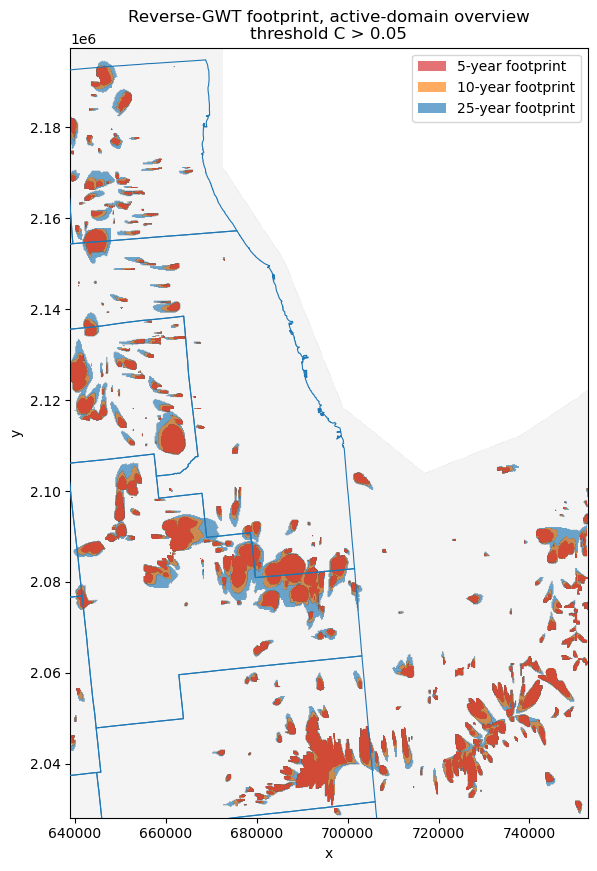

,year,output_year,plan-view cells above threshold
0,5.0,5.0,22003
1,10.0,10.0,30024
2,25.0,25.0,40833


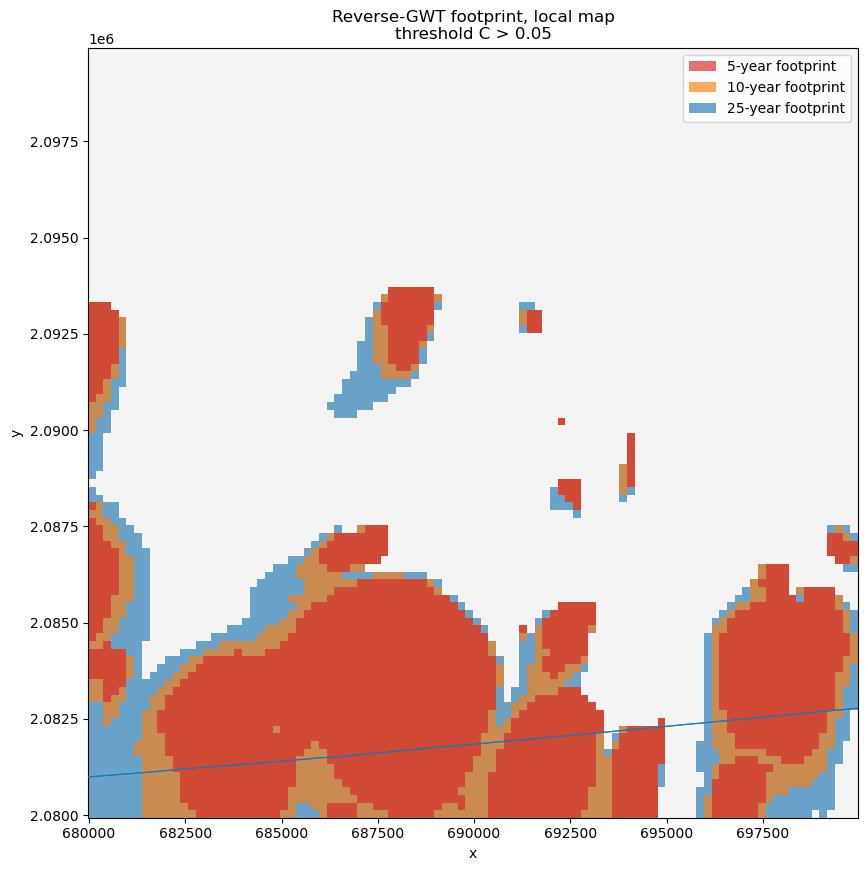

,year,output_year,plan-view cells above threshold
0,5.0,5.0,22003
1,10.0,10.0,30024
2,25.0,25.0,40833


In [17]:
def plot_reverse_gwt_footprints(mode="active_domain", title="Reverse-GWT transport footprint"):
    idomain = np.asarray(reverse_forward_gwf.dis.idomain.array)
    masks, times = capture_masks(
        reverse_gwt,
        reverse_forward_gwf,
        reverse_output_years,
        capture_concentration_threshold,
        days_per_year=days_per_year,
    )

    if mode == "active_domain":
        row0, row1, col0, col1 = active_window(idomain, active_domain_pad_cells)
    else:
        row0, row1, col0, col1 = xy_window(
            reverse_forward_gwf,
            idomain,
            local_capture_x_min,
            local_capture_x_max,
            local_capture_y_min,
            local_capture_y_max,
        )

    xmin, xmax, ymin, ymax = window_extent(reverse_forward_gwf, row0, row1, col0, col1)
    counties = model_counties(reverse_forward_gwf).cx[xmin:xmax, ymin:ymax]

    colors = {5.0: "tab:red", 10.0: "tab:orange", 25.0: "tab:blue"}

    fig, ax = plt.subplots(figsize=(11, 10))
    ax.set_aspect("equal")

    active = np.any(idomain > 0, axis=0)[row0:row1, col0:col1]
    ax.imshow(
        np.where(active, 1.0, np.nan),
        origin="upper",
        extent=[xmin, xmax, ymin, ymax],
        cmap=ListedColormap(["lightgray"]),
        alpha=0.25,
        zorder=0,
    )

    # Draw the largest time window first, then stack shorter travel times on top.
    for year in sorted(reverse_output_years, reverse=True):
        zone = masks[float(year)][row0:row1, col0:col1]
        ax.imshow(
            np.where(zone, 1.0, np.nan),
            origin="upper",
            extent=[xmin, xmax, ymin, ymax],
            cmap=ListedColormap([colors[float(year)]]),
            alpha=0.65,
            zorder=2,
        )

    if len(counties) > 0:
        counties.boundary.plot(ax=ax, linewidth=0.8, zorder=4)

    handles = [
        Patch(facecolor=colors[float(year)], alpha=0.65, label=f"{year:g}-year footprint")
        for year in sorted(reverse_output_years)
    ]
    ax.legend(handles=handles, loc="upper right")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}\nthreshold C > {capture_concentration_threshold:g}")
    plt.show()

    footprint_summary = []
    for year in sorted(reverse_output_years):
        footprint_summary.append(
            {
                "year": year,
                "output_year": times[float(year)] / days_per_year,
                "plan-view cells above threshold": int(masks[float(year)].sum()),
            }
        )
    display(pd.DataFrame(footprint_summary))


plot_reverse_gwt_footprints(mode="active_domain", title="Reverse-GWT footprint, active-domain overview")
plot_reverse_gwt_footprints(mode="local", title="Reverse-GWT footprint, local map")


## 16. Prepare the steady flow field for particle tracking

This is where the notebook turns from regional groundwater age to capture-zone pathlines.

The age maps show how long water has been moving through the aquifer system on average. Particle tracking asks a more local question: for water that reaches pumping wells, where could it have come from over 5, 10, and 25 years?

This section prepares the steady flow field used by PRT, reverses the flow information for backtracking, selects six representative pumping wells at random across the model domain while avoiding abrupt local K changes, and creates release points near the top and bottom of each selected well cell. The goal is to produce a small set of readable capture-zone examples that can be inspected well by well.


In [ ]:
# ---------------------------------------------------------------------
# Particle-tracking settings.
# ---------------------------------------------------------------------
prt_workspace = Path(home_dir / "modflow_models" / "reverse_capture_prt")
prt_flow_workspace = Path(home_dir / "modflow_models" / "reverse_capture_prt_steady_flow")
prt_model_name = "rvcap_prt"  # MF6 model names must stay short.

prt_marker_years = [5.0, 10.0, 25.0]
prt_lookback_years = max(prt_marker_years)
prt_lookback_days = prt_lookback_years * days_per_year

# PRT pathlines need enough saved positions to draw lines, not just endpoints.
# TRACK_EXIT records cell-exit points; the user times make the 5/10/25-year
# positions easy to mark on the plot.
prt_pathline_interval_years = 0.5
prt_track_years = np.arange(
    prt_pathline_interval_years,
    prt_lookback_years + 0.5 * prt_pathline_interval_years,
    prt_pathline_interval_years,
)
prt_track_years = sorted(set(np.round(np.r_[prt_track_years, prt_marker_years], 8)))
prt_track_times = [float(year) * days_per_year for year in prt_track_years]

# Release particles from named pumping wells in the selected layer.
prt_release_layer = analysis_layer
prt_release_boundname_prefix = "wel_"
prt_release_exclude_name_patterns = ["perimeter", "boundary", "flux", "edge"]

# Select six Illinois pumping wells for presentation.
# This is intentionally simple and participatory: one random saturated
# named pumping-well cell is selected from each Illinois county/area bucket.
# No transmissivity screen. No K-uniformity screen. Random mayhem, but spread out.
prt_random_seed = None
prt_selection_targets = [
    "Kankakee",
    "Will",
    "Southern Cook",
    "Northern Cook",
    "DuPage",
    "Lake",
]
prt_county_name_column = None  # auto-detect from county_shapefile

# A matched six-well reverse-GWT run is used later as a cleaner backdrop
# for the particle-tracking comparison panels. The earlier all-well reverse-
# GWT run is still kept in the notebook as the regional screening result.
run_reverse_gwt_selected = True

# Release particles near the bottom and near the top of the saturated
# portion of each selected well cell. At each vertical level, the release
# pattern uses one center point plus 99 points around a ring, giving
# 100 release particles at the bottom and 100 at the top.
prt_include_center_particle = True
prt_ring_particle_count = 99
prt_ring_radius_fraction = 0.30
prt_localz_min = 1.0e-7
prt_localz_top_buffer = 1.0e-7
prt_vertical_release_labels = ["Bottom of saturated interval", "Top of saturated interval"]

run_prt_steady_flow = True
run_prt = True

prt_design_summary = pd.DataFrame(
    [
        {"item": "Highlighted tracking times", "value": ", ".join(f"{y:g} years" for y in prt_marker_years)},
        {"item": "Pathline output interval", "value": f"{prt_pathline_interval_years:g} years"},
        {"item": "Release layer", "value": f"Layer {prt_release_layer + 1}"},
        {"item": "Representative wells", "value": len(prt_selection_targets)},
        {"item": "Particles per well at bottom", "value": int(prt_include_center_particle) + prt_ring_particle_count},
        {"item": "Particles per well at top", "value": int(prt_include_center_particle) + prt_ring_particle_count},
        {"item": "Target particles per well", "value": 2 * (int(prt_include_center_particle) + prt_ring_particle_count)},
        {"item": "Transport porosity", "value": transport_porosity},
    ]
)
display(prt_design_summary)

prt_workspace.mkdir(parents=True, exist_ok=True)
prt_flow_workspace.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------
# 1. Create a steady-flow support run for PRT.
# ---------------------------------------------------------------------
prt_flow_workspace.mkdir(parents=True, exist_ok=True)

prt_flow_sim = flopy.mf6.MFSimulation.load(
    sim_name=sim_name,
    sim_ws=base_model_workspace,
    write_headers=False,
    exe_name=exe_name,
    verbosity_level=0,
)

prt_flow_sim.set_sim_path(prt_flow_workspace)

prt_flow_model_name = list(prt_flow_sim.model_names)[0]
prt_flow_gwf = prt_flow_sim.get_model(prt_flow_model_name)

prt_start_heads, prt_base_final_time = final_heads_from_base(base_gwf, prt_flow_gwf)
prt_flow_gwf.ic.strt.set_data(prt_start_heads)

prt_flow_sim.tdis.nper = 1
prt_flow_sim.tdis.perioddata = [(prt_lookback_days, 1, 1.0)]

if prt_flow_gwf.get_package("sto") is not None:
    prt_flow_gwf.sto.steady_state.set_data({0: True})
    prt_flow_gwf.sto.transient.set_data({0: False})

prt_forward_head_file = prt_flow_workspace / f"{prt_flow_gwf.name}.hds"
prt_forward_budget_file = prt_flow_workspace / f"{prt_flow_gwf.name}.cbc"

prt_flow_gwf.oc.head_filerecord.set_data(prt_forward_head_file.name)
prt_flow_gwf.oc.budget_filerecord.set_data(prt_forward_budget_file.name)
prt_flow_gwf.oc.saverecord.set_data({0: [("HEAD", "LAST"), ("BUDGET", "LAST")]})
prt_flow_gwf.oc.printrecord.set_data({0: [("BUDGET", "LAST")]})

turn_on_flow_output(prt_flow_gwf)
prt_flow_sim.write_simulation(silent=True)

if run_prt_steady_flow:
    success, buff = prt_flow_sim.run_simulation(silent=False, report=True)
    if not success:
        raise RuntimeError("Steady-flow support run for PRT failed.")
else:
    print("Steady-flow support model was written. The run flag is off, so existing flow outputs will be used if available.")

# ---------------------------------------------------------------------
# 2. Reverse the steady head and budget files for backward tracking.
# ---------------------------------------------------------------------
prt_reverse_head_file = prt_workspace / f"{prt_flow_gwf.name}_steady_reverse.hds"
prt_reverse_budget_file = prt_workspace / f"{prt_flow_gwf.name}_steady_reverse.cbc"

headobj = bf.HeadFile(str(prt_forward_head_file), tdis=prt_flow_sim.tdis)
headobj.reverse(filename=str(prt_reverse_head_file))

cbb = bf.CellBudgetFile(str(prt_forward_budget_file), tdis=prt_flow_sim.tdis)
cbb.reverse(filename=str(prt_reverse_budget_file))

# ---------------------------------------------------------------------
# Flow-direction check for the pathline model.
# ---------------------------------------------------------------------
# The head field stays the same; the tracking direction is reversed so that
# particles can move backward from wells toward source areas.

prt_headobj = bf.HeadFile(str(prt_forward_head_file), tdis=prt_flow_sim.tdis)
prt_head_time = prt_headobj.get_times()[-1]
prt_heads = np.asarray(prt_headobj.get_data(totim=prt_head_time), dtype=float)
prt_idomain = np.asarray(prt_flow_gwf.dis.idomain.array)
prt_head_layer = np.where(prt_idomain[analysis_layer] > 0, prt_heads[analysis_layer], np.nan)

prt_qx = prt_qy = None
try:
    prt_budget_obj = bf.CellBudgetFile(str(prt_forward_budget_file), tdis=prt_flow_sim.tdis)
    prt_spdis = prt_budget_obj.get_data(text="DATA-SPDIS", totim=prt_head_time)[0]
    prt_qx, prt_qy, prt_qz = flopy.utils.postprocessing.get_specific_discharge(prt_spdis, prt_flow_gwf)
except Exception:
    pass

row0, row1, col0, col1 = xy_window(
    prt_flow_gwf,
    prt_idomain,
    local_map_x_min,
    local_map_x_max,
    local_map_y_min,
    local_map_y_max,
)
xmin, xmax, ymin, ymax = window_extent(prt_flow_gwf, row0, row1, col0, col1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
flow_titles = ["Forward groundwater movement", "Backtracking direction used by PRT"]
flow_signs = [1.0, -1.0]

valid_heads = prt_head_layer[np.isfinite(prt_head_layer)]
levels = np.linspace(np.nanpercentile(valid_heads, 5), np.nanpercentile(valid_heads, 95), 10) if valid_heads.size else 10

for ax, title, sign in zip(axes, flow_titles, flow_signs):
    im = ax.imshow(
        np.ma.masked_invalid(prt_head_layer[row0:row1, col0:col1]),
        origin="upper",
        extent=[xmin, xmax, ymin, ymax],
    )
    ax.contour(
        prt_flow_gwf.modelgrid.xcellcenters[row0:row1, col0:col1],
        prt_flow_gwf.modelgrid.ycellcenters[row0:row1, col0:col1],
        prt_head_layer[row0:row1, col0:col1],
        levels=levels,
        linewidths=0.5,
    )
    if prt_qx is not None and prt_qy is not None:
        step = max(1, int(max(row1 - row0, col1 - col0) / 20))
        qx_local = sign * prt_qx[analysis_layer, row0:row1:step, col0:col1:step]
        qy_local = sign * prt_qy[analysis_layer, row0:row1:step, col0:col1:step]
        x_local = prt_flow_gwf.modelgrid.xcellcenters[row0:row1:step, col0:col1:step]
        y_local = prt_flow_gwf.modelgrid.ycellcenters[row0:row1:step, col0:col1:step]
        good = np.isfinite(qx_local) & np.isfinite(qy_local)
        ax.quiver(x_local[good], y_local[good], qx_local[good], qy_local[good], angles="xy", scale_units="xy", scale=None, width=0.003, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")

fig.colorbar(im, ax=axes, shrink=0.8, label="Head")
fig.suptitle(f"Flow field used for particle tracking, layer {analysis_layer + 1}", y=1.02)
plt.show()

flow_tracking_summary = pd.DataFrame(
    [
        {"item": "Flow model used for PRT", "value": prt_flow_model_name},
        {"item": "Tracking direction", "value": "Backward from pumping wells using reversed flow information"},
        {"item": "Head and budget files prepared", "value": "Yes"},
        {"item": "Flow arrows available", "value": prt_qx is not None and prt_qy is not None},
    ]
)
display(flow_tracking_summary)

# ---------------------------------------------------------------------
# 3. Select representative Illinois pumping wells.
# ---------------------------------------------------------------------
all_release_cells, all_well_table, prt_release_excluded, prt_wel_pkg, prt_wel_pname = pumping_well_release_cells(
    prt_flow_gwf,
    kper=0,
    layer=prt_release_layer,
    boundname_prefix=prt_release_boundname_prefix,
    exclude_name_patterns=prt_release_exclude_name_patterns,
)

if len(all_release_cells) == 0:
    raise RuntimeError(
        "No pumping-well release cells were selected for PRT. "
        "Check the release layer or WEL package."
    )

xcenters = np.asarray(prt_flow_gwf.modelgrid.xcellcenters, dtype=float)
ycenters = np.asarray(prt_flow_gwf.modelgrid.ycellcenters, dtype=float)
all_well_table = all_well_table.copy()
all_well_table["x"] = [xcenters[int(i), int(j)] for i, j in zip(all_well_table["i"], all_well_table["j"])]
all_well_table["y"] = [ycenters[int(i), int(j)] for i, j in zip(all_well_table["i"], all_well_table["j"])]
all_well_table["well_id"] = [
    f"k{int(k)}_i{int(i)}_j{int(j)}"
    for k, i, j in zip(all_well_table["k"], all_well_table["i"], all_well_table["j"])
]
all_well_table["abs_q_total"] = all_well_table["q_total"].abs()

# Read local hydraulic properties for reporting and to confirm saturated thickness.
# These values are not used to screen/select the wells.
prt_top = np.asarray(prt_flow_gwf.dis.top.array, dtype=float)
prt_botm = np.asarray(prt_flow_gwf.dis.botm.array, dtype=float)

k_array_raw = np.asarray(prt_flow_gwf.npf.k.array, dtype=float)
shape = (prt_flow_gwf.modelgrid.nlay, prt_flow_gwf.modelgrid.nrow, prt_flow_gwf.modelgrid.ncol)
if k_array_raw.ndim == 0:
    k_array = np.full(shape, float(k_array_raw), dtype=float)
elif k_array_raw.ndim == 1 and k_array_raw.shape[0] == shape[0]:
    k_array = np.repeat(k_array_raw[:, None, None], shape[1], axis=1)
    k_array = np.repeat(k_array, shape[2], axis=2)
elif k_array_raw.ndim == 2 and k_array_raw.shape == shape[1:]:
    k_array = np.repeat(k_array_raw[None, :, :], shape[0], axis=0)
else:
    k_array = np.broadcast_to(k_array_raw, shape).astype(float)

sat_thickness = []
transmissivity = []
k_local_list = []
for row in all_well_table.itertuples(index=False):
    k = int(row.k)
    i = int(row.i)
    j = int(row.j)
    layer_top = prt_top[i, j] if k == 0 else prt_botm[k - 1, i, j]
    layer_bot = prt_botm[k, i, j]
    head = prt_heads[k, i, j]
    if np.isfinite(head) and np.isfinite(layer_top) and np.isfinite(layer_bot):
        sat_top = min(head, layer_top)
        b_sat = max(0.0, sat_top - layer_bot)
    else:
        b_sat = np.nan
    kval = float(k_array[k, i, j])
    tval = kval * b_sat if np.isfinite(b_sat) else np.nan
    sat_thickness.append(float(b_sat) if np.isfinite(b_sat) else np.nan)
    k_local_list.append(kval)
    transmissivity.append(float(tval) if np.isfinite(tval) else np.nan)

all_well_table["saturated_thickness"] = sat_thickness
all_well_table["K_local"] = k_local_list
all_well_table["T_local"] = transmissivity

candidate_wells = all_well_table[
    np.isfinite(all_well_table["saturated_thickness"])
    & (all_well_table["saturated_thickness"] > 0)
].copy()

if len(candidate_wells) == 0:
    raise RuntimeError("No saturated named pumping-well cells were available for selection.")

# Assign candidate wells to Illinois counties using the county shapefile.
counties_for_selection = model_counties(prt_flow_gwf)
county_name_col = prt_county_name_column or find_county_name_column(counties_for_selection)
counties_for_selection = counties_for_selection.copy()
counties_for_selection["county_clean"] = counties_for_selection[county_name_col].map(normalize_county_name)

illinois_counties = counties_for_selection[
    counties_for_selection["county_clean"].isin(["kankakee", "will", "cook", "dupage", "lake"])
].copy()

if len(illinois_counties) == 0:
    raise RuntimeError("Could not find the requested Illinois counties in county_shapefile.")

well_points = gpd.GeoDataFrame(
    candidate_wells,
    geometry=gpd.points_from_xy(candidate_wells["x"], candidate_wells["y"]),
    crs=counties_for_selection.crs,
)

candidate_wells_county = gpd.sjoin(
    well_points,
    illinois_counties[["county_clean", "geometry"]],
    how="inner",
    predicate="within",
).drop(columns=["index_right"]).copy()

if len(candidate_wells_county) == 0:
    raise RuntimeError("No saturated named pumping wells were found in the requested Illinois counties.")

# Split Cook County simply by the median y-coordinate of Cook candidate wells.
candidate_wells_county["selection_area"] = candidate_wells_county["county_clean"].str.title()
cook_mask = candidate_wells_county["county_clean"] == "cook"
cook_candidates = candidate_wells_county[cook_mask].copy()
if len(cook_candidates) > 0:
    cook_y_split = float(cook_candidates["y"].median())
    candidate_wells_county.loc[cook_mask & (candidate_wells_county["y"] < cook_y_split), "selection_area"] = "Southern Cook"
    candidate_wells_county.loc[cook_mask & (candidate_wells_county["y"] >= cook_y_split), "selection_area"] = "Northern Cook"
else:
    cook_y_split = np.nan

# Normalize DuPage capitalization for display.
candidate_wells_county["selection_area"] = candidate_wells_county["selection_area"].replace({"Dupage": "DuPage"})

rng = np.random.default_rng()
selected_rows = []

for target in prt_selection_targets:
    subset = candidate_wells_county[candidate_wells_county["selection_area"] == target].copy()
    if len(subset) == 0:
        raise RuntimeError(f"No saturated named pumping wells found for selection area: {target}")
    chosen = subset.sample(n=1, random_state=int(rng.integers(0, 1_000_000_000))).iloc[0]
    selected_rows.append(chosen)

selected_wells = pd.DataFrame(selected_rows).drop(columns=["geometry"], errors="ignore").reset_index(drop=True)
selected_wells["selected_well_number"] = np.arange(1, len(selected_wells) + 1)
selected_wells["well_label"] = [f"W{n}" for n in selected_wells["selected_well_number"]]

prt_well_release_table = selected_wells.copy()
prt_release_cells = [
    (int(row.k), int(row.i), int(row.j))
    for row in prt_well_release_table.itertuples(index=False)
]
selected_lookup = {
    (int(row.k), int(row.i), int(row.j)): {
        "well_label": row.well_label,
        "selected_well_number": int(row.selected_well_number),
        "boundnames": row.boundnames,
        "x": float(row.x),
        "y": float(row.y),
        "well_id": row.well_id,
    }
    for row in prt_well_release_table.itertuples(index=False)
}

selected_wells_path = prt_workspace / "selected_six_illinois_wells.csv"
prt_well_release_table.to_csv(selected_wells_path, index=False)

well_selection_summary = prt_well_release_table[
    [
        "well_label",
        "selection_area",
        "boundnames",
        "q_total",
        "K_local",
        "saturated_thickness",
        "T_local",
        "x",
        "y",
    ]
].copy()
well_selection_summary = well_selection_summary.rename(
    columns={
        "selection_area": "Selection area",
        "boundnames": "Well name(s)",
        "q_total": "Total pumping in selected cell",
        "K_local": "Local K",
        "saturated_thickness": "Saturated thickness",
        "T_local": "Local transmissivity",
    }
)
display(well_selection_summary)

# Overview map of all candidate pumping wells and the six selected examples.
idomain = np.asarray(prt_flow_gwf.dis.idomain.array)
row0_all, row1_all, col0_all, col1_all = active_window(idomain, active_domain_pad_cells)
xmin_all, xmax_all, ymin_all, ymax_all = window_extent(prt_flow_gwf, row0_all, row1_all, col0_all, col1_all)
counties_all = model_counties(prt_flow_gwf).cx[xmin_all:xmax_all, ymin_all:ymax_all]

fig, ax = plt.subplots(figsize=(10, 12))
ax.set_aspect("equal")
active = np.any(idomain > 0, axis=0)[row0_all:row1_all, col0_all:col1_all]
ax.imshow(
    np.where(active, 1.0, np.nan),
    origin="upper",
    extent=[xmin_all, xmax_all, ymin_all, ymax_all],
    cmap=ListedColormap(["lightgray"]),
    alpha=0.2,
    zorder=0,
)
if len(counties_all) > 0:
    counties_all.boundary.plot(ax=ax, linewidth=0.8, zorder=1)

ax.scatter(
    candidate_wells_county["x"],
    candidate_wells_county["y"],
    s=10,
    color="lightgray",
    alpha=0.6,
    zorder=2,
    label="Illinois saturated pumping-well candidates",
)

selection_colors = plt.get_cmap("tab10", len(prt_well_release_table))
for idx, row in prt_well_release_table.iterrows():
    color = selection_colors(idx)
    ax.scatter(row["x"], row["y"], s=90, color=color, edgecolor="black", linewidth=0.5, zorder=4)
    ax.text(row["x"], row["y"], row["well_label"], fontsize=9, ha="left", va="bottom", color="black", zorder=5)

ax.set_xlim(xmin_all, xmax_all)
ax.set_ylim(ymin_all, ymax_all)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Six random Illinois pumping wells selected for capture-zone examples")
ax.legend(loc="upper right")
plt.show()

selection_overview_summary = pd.DataFrame(
    [
        {"item": "Requested selection areas", "value": ", ".join(prt_selection_targets)},
        {"item": "Candidate Illinois saturated pumping-well cells", "value": len(candidate_wells_county)},
        {"item": "Selected wells", "value": len(prt_release_cells)},
        {"item": "Selection method", "value": "One random saturated named pumping-well cell per requested Illinois county/area"},
        {"item": "Cook split", "value": f"Median candidate-well y = {cook_y_split:.2f}" if np.isfinite(cook_y_split) else "No Cook candidates found"},
        {"item": "Selected well table", "value": str(selected_wells_path)},
        {"item": "Boundary/perimeter entries excluded", "value": len(prt_release_excluded)},
    ]
)
display(selection_overview_summary)

# ---------------------------------------------------------------------
# 4. Build release points near the top and bottom of each selected well cell.
# ---------------------------------------------------------------------
# PRT localz is a fraction of the full model cell thickness, measured from
# the cell bottom. For partially saturated cells, the top of the saturated
# interval may be below the model cell top. We therefore place particles at
# two elevations within the saturated interval: one near the bottom and one
# near the top. This lets the pathline examples show whether the upper and
# lower parts of the well cell connect to similar or different source areas.

prt_release_offsets = circular_release_offsets(
    n_ring=prt_ring_particle_count,
    radius=prt_ring_radius_fraction,
    include_center=prt_include_center_particle,
)

delr = np.asarray(prt_flow_gwf.dis.delr.array, dtype=float)
delc = np.asarray(prt_flow_gwf.dis.delc.array, dtype=float)

release_point_rows = []
diagnostic_rows = []
kept_cells = []

for particle_cell_index, (k, i, j) in enumerate(prt_release_cells, start=1):
    layer_top = prt_top[i, j] if k == 0 else prt_botm[k - 1, i, j]
    layer_bot = prt_botm[k, i, j]
    head = prt_heads[k, i, j]
    thickness = layer_top - layer_bot
    saturated_top = min(head, layer_top) if np.isfinite(head) and np.isfinite(layer_top) else np.nan
    saturated_thickness = saturated_top - layer_bot if np.isfinite(saturated_top) and np.isfinite(layer_bot) else np.nan

    cell_has_saturated_thickness = (
        np.isfinite(head)
        and np.isfinite(layer_top)
        and np.isfinite(layer_bot)
        and thickness > 0
        and saturated_thickness > 0
    )

    if cell_has_saturated_thickness:
        saturated_top_localz = (saturated_top - layer_bot) / thickness
        zmax = min(1.0 - prt_localz_top_buffer, saturated_top_localz - prt_localz_top_buffer)
        zmin = max(prt_localz_min, 0.0 + prt_localz_min)
        if zmax > zmin:
            localz_values = np.array([zmin, zmax], dtype=float)
            vertical_labels = list(prt_vertical_release_labels)
        else:
            midpoint = max(zmin, min(0.5 * (zmin + zmax), 1.0 - prt_localz_top_buffer))
            localz_values = np.array([midpoint], dtype=float)
            vertical_labels = ["Saturated interval"]
    else:
        saturated_top_localz = np.nan
        localz_values = np.array([], dtype=float)
        vertical_labels = []

    diagnostic_rows.append(
        {
            "particle_cell_index": particle_cell_index,
            "k": int(k),
            "i": int(i),
            "j": int(j),
            "head": float(head),
            "layer_top": float(layer_top),
            "layer_bot": float(layer_bot),
            "cell_thickness": float(thickness),
            "saturated_top": float(saturated_top) if np.isfinite(saturated_top) else np.nan,
            "saturated_thickness": float(saturated_thickness) if np.isfinite(saturated_thickness) else np.nan,
            "saturated_top_localz": float(saturated_top_localz) if np.isfinite(saturated_top_localz) else np.nan,
            "n_vertical_positions": int(len(localz_values)),
            "cell_has_saturated_thickness": bool(cell_has_saturated_thickness),
        }
    )

    if len(localz_values) == 0:
        continue

    kept_cells.append((int(k), int(i), int(j)))
    info = selected_lookup[(int(k), int(i), int(j))]

    for vertical_label, localz in zip(vertical_labels, localz_values):
        for _, offset in prt_release_offsets.iterrows():
            localx = float(offset["localx"])
            localy = float(offset["localy"])
            x_plot = xcenters[i, j] + (localx - 0.5) * delr[j]
            y_plot = ycenters[i, j] + (localy - 0.5) * delc[i]
            release_point_rows.append(
                {
                    "particle_cell_index": particle_cell_index,
                    "well_label": info["well_label"],
                    "selected_well_number": info["selected_well_number"],
                    "well_id": info["well_id"],
                    "boundnames": info["boundnames"],
                    "k": int(k),
                    "i": int(i),
                    "j": int(j),
                    "localx": localx,
                    "localy": localy,
                    "localz": float(localz),
                    "vertical_release": vertical_label,
                    "release_position": offset["release_position"],
                    "x": float(x_plot),
                    "y": float(y_plot),
                    "well_x": info["x"],
                    "well_y": info["y"],
                }
            )

prt_release_diagnostics = pd.DataFrame(diagnostic_rows)
prt_release_cells = kept_cells
prt_release_point_table = pd.DataFrame(release_point_rows)
if len(prt_release_cells) == 0 or len(prt_release_point_table) == 0:
    raise RuntimeError("No PRT release particles remain after checking saturated release intervals.")

prt_release_point_table = prt_release_point_table.reset_index(drop=True)
prt_release_point_table["irpt0"] = np.arange(len(prt_release_point_table), dtype=int)
prt_release_point_table["irpt1"] = prt_release_point_table["irpt0"] + 1
prt_release_points_xy = prt_release_point_table.copy()

release_summary = pd.DataFrame(
    [
        {
            "candidate_release_cells": len(prt_release_diagnostics),
            "cells_with_saturated_thickness": int(prt_release_diagnostics["cell_has_saturated_thickness"].sum()),
            "release_cells_kept": len(prt_release_cells),
            "vertical_release_levels_per_well": int(prt_release_diagnostics.loc[prt_release_diagnostics["n_vertical_positions"] > 0, "n_vertical_positions"].median()),
            "lateral_positions_per_release_level": len(prt_release_offsets),
            "target_particles_per_well": int(2 * len(prt_release_offsets)),
            "actual_total_release_particles": len(prt_release_point_table),
            "minimum_saturated_top_localz": float(prt_release_diagnostics["saturated_top_localz"].min()),
            "median_saturated_top_localz": float(prt_release_diagnostics["saturated_top_localz"].median()),
        }
    ]
)
display(release_summary)

release_diagnostics_path = prt_workspace / "prt_release_saturation_diagnostics.csv"
prt_release_diagnostics.to_csv(release_diagnostics_path, index=False)

prt_porosity = np.full(
    (
        prt_flow_gwf.modelgrid.nlay,
        prt_flow_gwf.modelgrid.nrow,
        prt_flow_gwf.modelgrid.ncol,
    ),
    transport_porosity,
    dtype=float,
)

prt_release_summary = pd.DataFrame(
    [
        {"item": "Selected representative wells", "value": len(prt_release_cells)},
        {"item": "Particles released per well", "value": int(len(prt_release_point_table) / len(prt_release_cells)) if len(prt_release_cells) else 0},
        {"item": "Bottom release level", "value": prt_vertical_release_labels[0]},
        {"item": "Top release level", "value": prt_vertical_release_labels[1]},
        {"item": "Total release particles", "value": len(prt_release_point_table)},
        {"item": "Porosity used for particle travel time", "value": transport_porosity},
        {"item": "Release diagnostic table", "value": str(release_diagnostics_path)},
    ]
)
display(prt_release_summary)


## 17A. Build a matched reverse-GWT run for the same six wells

The earlier reverse-GWT run still uses **all named pumping wells** and remains the broad screening map for the study area. For the six-well comparison panels, however, it is helpful to run a second reverse-GWT case using **the same six wells selected for particle tracking**. That keeps the comparison cleaner: the reverse-GWT footprint and the PRT pathlines are then both responding to the same six pumping wells.

In [ ]:
# ---------------------------------------------------------------------
# Build a matched reverse-GWT run for the same six selected wells.
# ---------------------------------------------------------------------
selected_cell_set = {
    (int(row.k), int(row.i), int(row.j))
    for row in prt_well_release_table.itertuples(index=False)
}

reverse_selected_sources = reverse_wel_selected[
    reverse_wel_selected.apply(
        lambda row: (int(row["k"]), int(row["i"]), int(row["j"])) in selected_cell_set,
        axis=1,
    )
].copy()

if len(reverse_selected_sources) == 0:
    raise RuntimeError("No reverse-GWT source entries matched the six selected PRT wells.")

reverse_selected_workspace = Path(home_dir / "modflow_models" / "reverse_capture_gwt_selected6")
reverse_selected_workspace.mkdir(parents=True, exist_ok=True)

reverse_selected_spc_file = reverse_selected_workspace / f"{reverse_wel_pname}_selected6.spc6"
write_spc6_file(
    spc_path=reverse_selected_spc_file,
    bndnos=reverse_selected_sources["bndno"].astype(int).tolist(),
    concentration=reverse_source_concentration,
    maxbound=reverse_wel_maxbound,
)

reverse_selected_gwt_name = "rvcap6_gwt"
reverse_selected_gwt_sim = flopy.mf6.MFSimulation(
    sim_name="reverse_capture_gwt_selected6_sim",
    sim_ws=reverse_selected_workspace,
    exe_name=exe_name,
)

flopy.mf6.ModflowTdis(
    reverse_selected_gwt_sim,
    time_units="DAYS",
    nper=reverse_nper,
    perioddata=reverse_perioddata,
)

reverse_selected_gwt = flopy.mf6.ModflowGwt(
    reverse_selected_gwt_sim,
    modelname=reverse_selected_gwt_name,
    save_flows=True,
)

flopy.mf6.ModflowGwtdis(
    reverse_selected_gwt,
    nlay=reverse_forward_gwf.dis.nlay.array,
    nrow=reverse_forward_gwf.dis.nrow.array,
    ncol=reverse_forward_gwf.dis.ncol.array,
    delr=reverse_forward_gwf.dis.delr.array,
    delc=reverse_forward_gwf.dis.delc.array,
    top=reverse_forward_gwf.dis.top.array,
    botm=reverse_forward_gwf.dis.botm.array,
    idomain=reverse_forward_gwf.dis.idomain.array,
    xorigin=reverse_forward_gwf.modelgrid.xoffset,
    yorigin=reverse_forward_gwf.modelgrid.yoffset,
    angrot=reverse_forward_gwf.modelgrid.angrot,
)

flopy.mf6.ModflowGwtic(reverse_selected_gwt, strt=0.0)
flopy.mf6.ModflowGwtadv(reverse_selected_gwt, scheme="UPSTREAM")

reverse_selected_porosity = np.full(
    (
        reverse_forward_gwf.modelgrid.nlay,
        reverse_forward_gwf.modelgrid.nrow,
        reverse_forward_gwf.modelgrid.ncol,
    ),
    transport_porosity,
    dtype=float,
)

flopy.mf6.ModflowGwtmst(
    reverse_selected_gwt,
    porosity=reverse_selected_porosity,
    save_flows=True,
)

flopy.mf6.ModflowGwtfmi(
    reverse_selected_gwt,
    save_flows=True,
    packagedata=[
        ("GWFHEAD", str(reverse_head_file)),
        ("GWFBUDGET", str(reverse_budget_file)),
    ],
)

flopy.mf6.ModflowGwtssm(
    reverse_selected_gwt,
    print_flows=True,
    save_flows=True,
    fileinput=[
        (reverse_wel_pname, str(reverse_selected_spc_file)),
    ],
)

reverse_selected_oc_records = {0: [("CONCENTRATION", "STEPS", *reverse_output_steps)]}
flopy.mf6.ModflowGwtoc(
    reverse_selected_gwt,
    concentration_filerecord=f"{reverse_selected_gwt_name}.ucn",
    saverecord=reverse_selected_oc_records,
    printrecord=reverse_selected_oc_records,
)

reverse_selected_ims = flopy.mf6.ModflowIms(
    reverse_selected_gwt_sim,
    filename=f"{reverse_selected_gwt_name}.ims",
    print_option="summary",
    complexity="simple",
    outer_maximum=100,
    inner_maximum=100,
    outer_dvclose=1.0e-6,
    inner_dvclose=1.0e-6,
    linear_acceleration="bicgstab",
)
reverse_selected_gwt_sim.register_ims_package(
    reverse_selected_ims,
    model_list=[reverse_selected_gwt.name],
)

reverse_selected_gwt_sim.write_simulation()
if run_reverse_gwt_selected:
    success, buff = reverse_selected_gwt_sim.run_simulation(silent=False, report=True)
    if not success:
        raise RuntimeError("Matched six-well reverse-GWT run failed.")
else:
    print("Matched six-well reverse-GWT model was written. Existing outputs will be used if available.")

reverse_selected_masks, reverse_selected_times = capture_masks(
    reverse_selected_gwt,
    reverse_forward_gwf,
    reverse_output_years,
    capture_concentration_threshold,
    days_per_year=days_per_year,
)

reverse_selected_summary = pd.DataFrame(
    [
        {"item": "Matched reverse-GWT source cells", "value": len(selected_cell_set)},
        {"item": "Matched reverse-GWT source entries", "value": len(reverse_selected_sources)},
        {"item": "Saved concentration years", "value": ", ".join(f"{reverse_selected_times[float(y)] / days_per_year:.1f}" for y in reverse_output_years)},
        {"item": "Concentration threshold for comparison panels", "value": f"C > {capture_concentration_threshold:g}"},
    ]
)
display(reverse_selected_summary)


## 17B. Build and run the PRT model

PRT runs as its own MODFLOW 6 simulation. It uses the same grid as the steady support model, the reversed steady-flow files, the shared porosity value, and the release points created from the six selected pumping-well cells.

The particle-tracking result is advective. It follows the modeled flow field and shows where water reaching those wells may have come from over 5, 10, and 25 years.

For each selected well cell, the release design places 100 particles near the bottom of the saturated interval and 100 particles near the top. Output control saves release points, cell-exit locations, selected tracking times, and termination records so the pathlines can be drawn as continuous traces rather than isolated dots.


In [ ]:
# ---------------------------------------------------------------------
# Build the PRT simulation against the reversed steady-flow files.
# ---------------------------------------------------------------------
prt_sim = flopy.mf6.MFSimulation(
    sim_name="reverse_capture_prt_sim",
    sim_ws=prt_workspace,
    exe_name=exe_name,
)

flopy.mf6.ModflowTdis(
    prt_sim,
    time_units="DAYS",
    nper=1,
    perioddata=[(prt_lookback_days, 1, 1.0)],
)

prt = flopy.mf6.ModflowPrt(
    prt_sim,
    modelname=prt_model_name,
    save_flows=True,
)

flopy.mf6.ModflowGwfdis(
    prt,
    nlay=prt_flow_gwf.dis.nlay.array,
    nrow=prt_flow_gwf.dis.nrow.array,
    ncol=prt_flow_gwf.dis.ncol.array,
    delr=prt_flow_gwf.dis.delr.array,
    delc=prt_flow_gwf.dis.delc.array,
    top=prt_flow_gwf.dis.top.array,
    botm=prt_flow_gwf.dis.botm.array,
    idomain=prt_flow_gwf.dis.idomain.array,
    xorigin=prt_flow_gwf.modelgrid.xoffset,
    yorigin=prt_flow_gwf.modelgrid.yoffset,
    angrot=prt_flow_gwf.modelgrid.angrot,
)

prt_izone = np.where(np.array(prt_flow_gwf.dis.idomain.array) > 0, 1, 0)
flopy.mf6.ModflowPrtmip(
    prt,
    pname="mip",
    porosity=prt_porosity,
    izone=prt_izone,
)

# ---------------------------------------------------------------------
# Build PRT release-point records directly.
# ---------------------------------------------------------------------
# FloPy's ParticleData.to_prp helper can be slow when the notebook releases
# many particles per well. We already created prt_release_point_table with
# the model cell and local position for each particle, so we write the PRT
# package records directly instead.
#
# PRT release-point packagedata format used here:
#     irptno, k, i, j, x, y, z
#
# The layer/row/column indices are zero-based for FloPy. The x/y coordinates
# are in the local MODFLOW model coordinate system, matching the format that
# ParticleData.to_prp would have produced.

print("Building particle-release records for PRT...")

release_table = prt_release_point_table.reset_index(drop=True).copy()

delr = np.asarray(prt_flow_gwf.dis.delr.array, dtype=float)
delc = np.asarray(prt_flow_gwf.dis.delc.array, dtype=float)
top = np.asarray(prt_flow_gwf.dis.top.array, dtype=float)
botm = np.asarray(prt_flow_gwf.dis.botm.array, dtype=float)

# Local model-coordinate cell centers. These are intentionally not projected
# map coordinates; the PRT package expects coordinates in the model grid.
x_left_edges = np.concatenate(([0.0], np.cumsum(delr[:-1])))
y_top_edges = np.concatenate(([np.sum(delc)], np.sum(delc) - np.cumsum(delc[:-1])))

release_points = []

for irpt0, row in enumerate(release_table.itertuples(index=False)):
    k = int(row.k)
    i = int(row.i)
    j = int(row.j)
    localx = float(row.localx)
    localy = float(row.localy)
    localz = float(row.localz)

    x = x_left_edges[j] + localx * delr[j]
    y = y_top_edges[i] - (1.0 - localy) * delc[i]

    layer_top = top[i, j] if k == 0 else botm[k - 1, i, j]
    layer_bot = botm[k, i, j]
    z = layer_bot + localz * (layer_top - layer_bot)

    release_points.append((irpt0, k, i, j, float(x), float(y), float(z)))

prt_release_record_summary = pd.DataFrame(
    [
        {"item": "Release cells", "value": len(prt_release_cells)},
        {"item": "Release particles", "value": len(release_points)},
        {"item": "Particles per release cell", "value": int(len(release_points) / len(prt_release_cells)) if len(prt_release_cells) else 0},
    ]
)
display(prt_release_record_summary)

flopy.mf6.ModflowPrtprp(
    prt,
    pname="prp",
    filename=f"{prt_model_name}.prp",
    nreleasepts=len(release_points),
    packagedata=release_points,
    perioddata={0: ["FIRST"]},
)

prt_budget_file = f"{prt_model_name}.bud"
prt_track_file = f"{prt_model_name}.trk"
prt_track_csv_file = f"{prt_model_name}.trk.csv"

flopy.mf6.ModflowPrtoc(
    prt,
    pname="oc",
    budget_filerecord=prt_budget_file,
    track_filerecord=prt_track_file,
    trackcsv_filerecord=prt_track_csv_file,
    track_release=True,
    track_exit=False,
    track_timestep=False,
    track_terminate=True,
    track_usertime=True,
    ntracktimes=len(prt_track_times),
    tracktimes=[(float(time),) for time in prt_track_times],
    saverecord=[("BUDGET", "LAST")],
)

flopy.mf6.ModflowPrtfmi(
    prt,
    packagedata=[
        ("GWFHEAD", str(prt_reverse_head_file)),
        ("GWFBUDGET", str(prt_reverse_budget_file)),
    ],
)

prt_ems = flopy.mf6.ModflowEms(
    prt_sim,
    pname="ems",
    filename=f"{prt_model_name}.ems",
)
prt_sim.register_solution_package(prt_ems, [prt.name])

prt_sim.write_simulation()

prt_oc_path = prt_workspace / f"{prt_model_name}.oc"
if prt_oc_path.exists():
    prt_oc_text = prt_oc_path.read_text()
    for required_keyword in ["TRACK_RELEASE", "TRACK_TERMINATE", "TRACK_USERTIME"]:
        if required_keyword not in prt_oc_text.upper():
            raise RuntimeError(f"Expected {required_keyword} in the PRT OC file, but it was not written.")

prt_output_request_summary = pd.DataFrame(
    [
        {"item": "Pathline records", "value": "release, cell exits, tracking times, and terminations"},
        {"item": "Highlighted years", "value": ", ".join(f"{y:g}" for y in prt_marker_years)},
        {"item": "Tracking-output records requested", "value": len(prt_track_times)},
    ]
)
display(prt_output_request_summary)

if run_prt:
    success, buff = prt_sim.run_simulation(silent=False, report=True)
    if not success:
        raise RuntimeError("PRT run failed. Check the PRT listing file.")
    print("PRT simulation completed successfully.")
else:
    print("PRT simulation was written. The run flag is off, so existing pathline output will be used if available.")

prt_track_csv_path = prt_workspace / prt_track_csv_file
prt_run_summary = pd.DataFrame(
    [
        {"item": "PRT workspace", "value": str(prt_workspace)},
        {"item": "Track CSV", "value": str(prt_track_csv_path)},
    ]
)
display(prt_run_summary)


## 18. Compare and plot the six selected capture zones

The next figures compare the six selected wells in two complementary ways. First, an overview map shows where the six wells sit in the active model domain and where the yearly particle positions fall across the region. Then the notebook zooms to each well and places the **matched six-well reverse-GWT footprints** beneath the **PRT yearly positions**. That focused comparison is less noisy than the all-well reverse-GWT backdrop and makes it easier to judge how similarly the two methods describe the same six pumping wells.

In [ ]:
prt_tracks = pd.read_csv(prt_track_csv_path)

if "t" in prt_tracks.columns:
    prt_time_col = "t"
elif "time" in prt_tracks.columns:
    prt_time_col = "time"
else:
    raise RuntimeError(f"Could not find a time column in PRT output. Columns: {list(prt_tracks.columns)}")

prt_id_cols = [col for col in ["iprp", "irpt"] if col in prt_tracks.columns]
if len(prt_id_cols) == 0:
    raise RuntimeError(f"Could not find particle ID columns in PRT output. Columns: {list(prt_tracks.columns)}")

for coord in ["x", "y"]:
    if coord not in prt_tracks.columns:
        raise RuntimeError(f"Could not find {coord!r} coordinate column in PRT output. Columns: {list(prt_tracks.columns)}")

prt_tracks[prt_time_col] = pd.to_numeric(prt_tracks[prt_time_col], errors="coerce")
prt_tracks["x"] = pd.to_numeric(prt_tracks["x"], errors="coerce")
prt_tracks["y"] = pd.to_numeric(prt_tracks["y"], errors="coerce")
prt_tracks = prt_tracks.dropna(subset=[prt_time_col, "x", "y"]).copy()
prt_tracks["year"] = prt_tracks[prt_time_col] / days_per_year

model_xmin, model_xmax, model_ymin, model_ymax = prt_flow_gwf.modelgrid.extent
raw_x = prt_tracks["x"].to_numpy(dtype=float)
raw_y = prt_tracks["y"].to_numpy(dtype=float)

try:
    transformed_x, transformed_y = prt_flow_gwf.modelgrid.get_coords(raw_x, raw_y)
except Exception:
    xoff = getattr(prt_flow_gwf.modelgrid, "xoffset", 0.0)
    yoff = getattr(prt_flow_gwf.modelgrid, "yoffset", 0.0)
    transformed_x = raw_x + xoff
    transformed_y = raw_y + yoff


def _count_inside_model(x, y):
    return int(
        np.sum(
            (x >= model_xmin)
            & (x <= model_xmax)
            & (y >= model_ymin)
            & (y <= model_ymax)
        )
    )


raw_inside = _count_inside_model(raw_x, raw_y)
transformed_inside = _count_inside_model(transformed_x, transformed_y)

if transformed_inside > raw_inside:
    prt_tracks["plot_x"] = transformed_x
    prt_tracks["plot_y"] = transformed_y
    prt_coordinate_mode = "modelgrid-transformed PRT coordinates"
else:
    prt_tracks["plot_x"] = raw_x
    prt_tracks["plot_y"] = raw_y
    prt_coordinate_mode = "raw PRT coordinates"

# Match each particle track back to the selected representative well.
lookup_cols = [
    "irpt0",
    "irpt1",
    "well_label",
    "selected_well_number",
    "well_id",
    "boundnames",
    "vertical_release",
    "well_x",
    "well_y",
]
release_lookup = prt_release_point_table[lookup_cols].copy()
if "iprp" not in prt_tracks.columns:
    prt_tracks["iprp"] = 1

tracks_zero = prt_tracks.merge(
    release_lookup.drop(columns=["irpt1"]),
    left_on="irpt",
    right_on="irpt0",
    how="left",
)
tracks_one = prt_tracks.merge(
    release_lookup.drop(columns=["irpt0"]),
    left_on="irpt",
    right_on="irpt1",
    how="left",
)

coverage_zero = tracks_zero["well_label"].notna().mean()
coverage_one = tracks_one["well_label"].notna().mean()
if coverage_one > coverage_zero:
    prt_tracks = tracks_one.copy()
    prt_track_lookup_mode = "one-based release-point numbering"
else:
    prt_tracks = tracks_zero.copy()
    prt_track_lookup_mode = "zero-based release-point numbering"

prt_tracks = prt_tracks[prt_tracks["well_label"].notna()].copy()
prt_tracks["selected_well_number"] = prt_tracks["selected_well_number"].astype(int)

prt_summary = (
    prt_tracks.groupby(prt_id_cols)
    .agg(
        first_year=("year", "min"),
        last_year=("year", "max"),
        n_points=("year", "size"),
    )
    .reset_index()
)

pathline_output_summary = pd.DataFrame(
    [
        {"item": "Particle-track records", "value": len(prt_tracks)},
        {"item": "Particles represented", "value": len(prt_summary)},
        {"item": "Median records per particle", "value": float(prt_summary["n_points"].median()) if len(prt_summary) else 0.0},
        {"item": "Maximum records for one particle", "value": int(prt_summary["n_points"].max()) if len(prt_summary) else 0},
        {"item": "Coordinate handling", "value": prt_coordinate_mode},
        {"item": "Release-point lookup", "value": prt_track_lookup_mode},
    ]
)
display(pathline_output_summary)

# ---------------------------------------------------------------------
# Build yearly plotting points.
# ---------------------------------------------------------------------
# The PRT output contains many saved positions. For presentation, convert that
# dense output into one plotted point per year so the capture zones can be
# compared more easily across the six selected wells.

plot_years = np.arange(1.0, prt_lookback_years + 1.0, 1.0)
plot_years_df = pd.DataFrame({"plot_year": plot_years})

tracks_with_years = prt_tracks.copy()
tracks_with_years["plot_year_key"] = np.round(tracks_with_years["year"]).astype(float)
tracks_with_years = tracks_with_years[np.isin(tracks_with_years["plot_year_key"], plot_years)].copy()
tracks_with_years["year_error"] = np.abs(tracks_with_years["year"] - tracks_with_years["plot_year_key"])

# Keep the closest record to each integer year for each particle.
yearly_points = (
    tracks_with_years.sort_values([*prt_id_cols, "plot_year_key", "year_error"])
    .groupby([*prt_id_cols, "plot_year_key"], as_index=False)
    .first()
    .rename(columns={"plot_year_key": "plot_year"})
)

# Assign the color groups requested for plotting.
def _year_group(year):
    if year <= 5:
        return "1-5 years"
    if year <= 10:
        return "6-10 years"
    return "11-25 years"


yearly_points["year_group"] = yearly_points["plot_year"].map(_year_group)
yearly_points["year_group_order"] = yearly_points["year_group"].map({"11-25 years": 0, "6-10 years": 1, "1-5 years": 2})

year_group_colors = {
    "1-5 years": "tab:red",
    "6-10 years": "tab:orange",
    "11-25 years": "tab:blue",
}

# Assign one display color to each selected well.
# This is only for plotting the selected well stars/labels.
well_cmap = plt.get_cmap("tab10", max(len(prt_well_release_table), 1))
well_colors = {
    row.well_label: well_cmap(idx)
    for idx, row in enumerate(prt_well_release_table.itertuples(index=False))
}

yearly_point_summary = (
    yearly_points.groupby(["well_label", "year_group"]).size().unstack(fill_value=0).reset_index()
)
display(yearly_point_summary)

# ---------------------------------------------------------------------
# Active-domain overview of the six selected PRT capture-zone examples
# ---------------------------------------------------------------------
# Uses existing yearly_points and selected-well tables.
# Red = yearly positions from years 1–5
# Orange = yearly positions from years 6–10
# Blue = yearly positions from years 11–25

counties = model_counties(prt_flow_gwf)

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_aspect("equal")

# Show the six selected wells in the broader active-domain context.
idomain = np.asarray(prt_flow_gwf.dis.idomain.array)
row0, row1, col0, col1 = active_window(idomain, active_domain_pad_cells)

overview_xlim = None
overview_ylim = None

if row0 is not None:
    x0, x1, y0, y1 = window_extent(prt_flow_gwf, row0, row1, col0, col1)
    overview_xlim = (x0, x1)
    overview_ylim = (y0, y1)

    active = np.any(idomain > 0, axis=0)[row0:row1, col0:col1]
    ax.imshow(
        np.where(active, 1.0, np.nan),
        origin="upper",
        extent=[x0, x1, y0, y1],
        cmap=ListedColormap(["lightgray"]),
        alpha=0.18,
        zorder=0,
    )

if overview_xlim is None or overview_ylim is None:
    overview_xlim = (
        np.nanmin(prt_flow_gwf.modelgrid.xcellcenters),
        np.nanmax(prt_flow_gwf.modelgrid.xcellcenters),
    )
    overview_ylim = (
        np.nanmin(prt_flow_gwf.modelgrid.ycellcenters),
        np.nanmax(prt_flow_gwf.modelgrid.ycellcenters),
    )

counties_plot = counties.cx[overview_xlim[0]:overview_xlim[1], overview_ylim[0]:overview_ylim[1]]
if len(counties_plot) > 0:
    counties_plot.boundary.plot(ax=ax, linewidth=0.8, zorder=1)

# Plot later years first, then shorter-time positions on top.
for group_name in ["11-25 years", "6-10 years", "1-5 years"]:
    group_df = yearly_points[yearly_points["year_group"] == group_name]
    ax.scatter(
        group_df["plot_x"],
        group_df["plot_y"],
        s=18,
        color=year_group_colors[group_name],
        edgecolor="black",
        linewidth=0.20,
        alpha=0.85,
        zorder=3 + ["11-25 years", "6-10 years", "1-5 years"].index(group_name),
        label=group_name,
    )

# Show release points and the six selected wells.
ax.scatter(
    prt_release_point_table["x"],
    prt_release_point_table["y"],
    s=6,
    color="black",
    alpha=0.30,
    zorder=2,
    label="PRT release points",
)

for row in prt_well_release_table.itertuples(index=False):
    ax.scatter(
        [row.x],
        [row.y],
        s=110,
        color=well_colors[row.well_label],
        edgecolor="black",
        linewidth=0.8,
        marker="*",
        zorder=7,
    )
    ax.text(
        row.x,
        row.y,
        row.well_label,
        fontsize=9,
        ha="left",
        va="bottom",
        color="black",
        zorder=8,
    )

ax.set_xlim(*overview_xlim)
ax.set_ylim(*overview_ylim)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(
    "Six selected PRT capture zones across the active model domain\n"
    "Yearly particle positions colored by travel-time interval"
)

overview_legend_handles = [
    Patch(facecolor=year_group_colors["1-5 years"], edgecolor="black", label="1–5 year positions"),
    Patch(facecolor=year_group_colors["6-10 years"], edgecolor="black", label="6–10 year positions"),
    Patch(facecolor=year_group_colors["11-25 years"], edgecolor="black", label="11–25 year positions"),
    Patch(facecolor="black", edgecolor="black", label="PRT release points"),
]
ax.legend(handles=overview_legend_handles, loc="upper right")

plt.show()

# ---------------------------------------------------------------------
# Individual capture-zone panels with matched six-well reverse-GWT backdrop.
# ---------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 11), constrained_layout=True)
axes = axes.ravel()

panel_reverse_zone_colors = {
    5.0: "tab:red",
    10.0: "tab:orange",
    25.0: "tab:blue",
}

panel_legend_handles = [
    Patch(facecolor=panel_reverse_zone_colors[5.0], alpha=0.28, edgecolor="black", label="GWT 5-year footprint"),
    Patch(facecolor=panel_reverse_zone_colors[10.0], alpha=0.28, edgecolor="black", label="GWT 10-year footprint"),
    Patch(facecolor=panel_reverse_zone_colors[25.0], alpha=0.28, edgecolor="black", label="GWT 25-year footprint"),
    Patch(facecolor=year_group_colors["1-5 years"], edgecolor="black", label="PRT 1–5 year positions"),
    Patch(facecolor=year_group_colors["6-10 years"], edgecolor="black", label="PRT 6–10 year positions"),
    Patch(facecolor=year_group_colors["11-25 years"], edgecolor="black", label="PRT 11–25 year positions"),
    Patch(facecolor="black", edgecolor="black", label="PRT release points"),
]

for ax, row in zip(axes, prt_well_release_table.itertuples(index=False)):
    well_yearly = yearly_points[yearly_points["well_label"] == row.well_label].copy()
    well_releases = prt_release_point_table[prt_release_point_table["well_label"] == row.well_label].copy()

    if len(well_yearly) == 0:
        ax.set_title(f"{row.well_label}: no yearly particle positions found")
        ax.axis("off")
        continue

    xvals = np.r_[well_yearly["plot_x"].to_numpy(dtype=float), well_releases["x"].to_numpy(dtype=float), float(row.x)]
    yvals = np.r_[well_yearly["plot_y"].to_numpy(dtype=float), well_releases["y"].to_numpy(dtype=float), float(row.y)]
    xmin = float(np.nanmin(xvals))
    xmax = float(np.nanmax(xvals))
    ymin = float(np.nanmin(yvals))
    ymax = float(np.nanmax(yvals))
    xrange = max(xmax - xmin, 1.0)
    yrange = max(ymax - ymin, 1.0)
    pad = max(800.0, 0.15 * max(xrange, yrange))
    xmin -= pad
    xmax += pad
    ymin -= pad
    ymax += pad

    active = np.any(idomain > 0, axis=0)
    xgrid = np.asarray(prt_flow_gwf.modelgrid.xcellcenters, dtype=float)
    ygrid = np.asarray(prt_flow_gwf.modelgrid.ycellcenters, dtype=float)
    inside = active & (xgrid >= xmin) & (xgrid <= xmax) & (ygrid >= ymin) & (ygrid <= ymax)
    if np.any(inside):
        r, c = np.where(inside)
        r0, r1 = int(r.min()), int(r.max()) + 1
        c0, c1 = int(c.min()), int(c.max()) + 1
        x0, x1, y0, y1 = window_extent(prt_flow_gwf, r0, r1, c0, c1)
        ax.imshow(
            np.where(active[r0:r1, c0:c1], 1.0, np.nan),
            origin="upper",
            extent=[x0, x1, y0, y1],
            cmap=ListedColormap(["lightgray"]),
            alpha=0.18,
            zorder=0,
        )

    rr0, rr1, cc0, cc1 = xy_window(
        reverse_forward_gwf,
        np.asarray(reverse_forward_gwf.dis.idomain.array),
        xmin,
        xmax,
        ymin,
        ymax,
    )
    gx0, gx1, gy0, gy1 = window_extent(reverse_forward_gwf, rr0, rr1, cc0, cc1)
    for year in sorted(reverse_output_years, reverse=True):
        zone = reverse_selected_masks[float(year)][rr0:rr1, cc0:cc1]
        ax.imshow(
            np.where(zone, 1.0, np.nan),
            origin="upper",
            extent=[gx0, gx1, gy0, gy1],
            cmap=ListedColormap([panel_reverse_zone_colors[float(year)]]),
            alpha=0.28,
            zorder=1,
        )

    counties_plot = counties.cx[xmin:xmax, ymin:ymax]
    if len(counties_plot) > 0:
        counties_plot.boundary.plot(ax=ax, linewidth=0.6, zorder=2)

    ax.scatter(
        well_releases["x"],
        well_releases["y"],
        s=5,
        color="black",
        alpha=0.28,
        zorder=3,
    )

    for group_name in ["11-25 years", "6-10 years", "1-5 years"]:
        group_df = well_yearly[well_yearly["year_group"] == group_name]
        ax.scatter(
            group_df["plot_x"],
            group_df["plot_y"],
            s=20,
            color=year_group_colors[group_name],
            edgecolor="black",
            linewidth=0.20,
            alpha=0.90,
            zorder=4 + ["11-25 years", "6-10 years", "1-5 years"].index(group_name),
        )

    ax.scatter(
        [row.x],
        [row.y],
        s=110,
        color=well_colors[row.well_label],
        edgecolor="black",
        linewidth=0.8,
        marker="*",
        zorder=8,
    )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(
        f"{row.well_label}: {row.boundnames}\n"
        f"Matched GWT backdrop + PRT yearly positions"
    )

for ax in axes[len(prt_well_release_table):]:
    ax.axis("off")

fig.legend(handles=panel_legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.03))
plt.show()

# Per-well comparison summary.
per_well_summary = (
    yearly_points.groupby(["well_label", "boundnames"])
    .agg(
        yearly_positions=("plot_year", "size"),
        min_year=("plot_year", "min"),
        max_year=("plot_year", "max"),
        xmin=("plot_x", "min"),
        xmax=("plot_x", "max"),
        ymin=("plot_y", "min"),
        ymax=("plot_y", "max"),
    )
    .reset_index()
)
per_well_summary["x_span"] = per_well_summary["xmax"] - per_well_summary["xmin"]
per_well_summary["y_span"] = per_well_summary["ymax"] - per_well_summary["ymin"]
display(per_well_summary[["well_label", "boundnames", "yearly_positions", "min_year", "max_year", "x_span", "y_span"]].sort_values("well_label"))


## 19. Reading the results together

The notebook now uses reverse-GWT in two complementary ways. Earlier, the **all-well reverse-GWT run** provides the broad regional transport footprint across the study area. In the comparison section, the **matched six-well reverse-GWT run** strips that problem down to the same six pumping wells used for particle tracking. That makes the method-to-method comparison cleaner and easier to read.

If the matched reverse-GWT footprints and the PRT yearly positions tell a similar story for the same six wells, that is encouraging. It suggests that the transport-based and pathline-based methods are highlighting similar source areas even though they summarize the flow system differently.